# Runoff Ratio Analysis

Here, we will first compare the results of all model types for the east river for wet, normal, and dry years between 2000 and 2021. 

Then we will analyze the runoff ratio variability from each model. We will also include a baseline SWE-Q regression model using the Butte snotel and observed streamflow relationship. 

In [1]:
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from pathlib import Path
import glob
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
repo_root = Path.cwd()
from utils.custom import linear_reservoir


## Analysis Setup


In [2]:
DATA_DIR = Path("/scratch/dlhogan/ess-project-data/")
DOMAIN = "East_River"
lumped_dir = DATA_DIR / f"domain_{DOMAIN}_lumped" / "simulations" / "best_simulations"
distributed_elev_dir = DATA_DIR / f"domain_{DOMAIN}_distributed" / "simulations" / "best_simulations"
distributed_elev_aspect_dir = DATA_DIR / f"domain_{DOMAIN}_distributed_elevAspect" / "simulations" / "best_simulations"
distributed_elev_TPI_dir = DATA_DIR / f"domain_{DOMAIN}_distributed_elevTPI" / "simulations" / "best_simulations"

In [3]:
# get East precipitation data from forcining
FORCING_DIR = Path(F"/scratch/dlhogan/ess-project-data/domain_{DOMAIN}_lumped/forcing")
precip_files = sorted(glob.glob(str(FORCING_DIR / "SUMMA_input" / "*metsim*.nc")))

ppt_dss = []
for file in precip_files:
    ds = xr.open_dataset(file)['pptrate'].resample(time='1D').mean()*3600*24
    ppt_dss.append(ds)
    ds.close()

# merge datasets
wy_precip = xr.concat(ppt_dss, dim='time').resample(time='YS-OCT').sum()
# winter_precip = xr.concat(ppt_dss, dim='time')
# # water year winter is december - march
# winter_precip = winter_precip.where(winter_precip['time.month'].isin([12, 1, 2, 3])).resample(time='YS-DEC').sum()

In [4]:
wy_precip_df = wy_precip.to_dataframe() 
# remove hru index
wy_precip_df = wy_precip_df.reset_index(level='hru')
wy_precip_df.index = wy_precip_df.index.year + 1

In [5]:
# observed streamflow
obs_streamflow = pd.read_csv(DATA_DIR / f"domain_{DOMAIN}_distributed" / "observations" / "formatted" / "streamflow_obs.csv", 
                             parse_dates=['date'], 
                             index_col='date')

In [6]:
lumped_files = sorted(glob.glob(str(lumped_dir / "*.nc")))
distributed_elev_files = sorted(glob.glob(str(distributed_elev_dir / "*.nc")))
distributed_elev_aspect_files = sorted(glob.glob(str(distributed_elev_aspect_dir / "*.nc")))
# distributed_elev_TPI_files = sorted(glob.glob(str(distributed_elev_TPI_dir / "*.nc")))

In [7]:
east_linear_reservoir_params = {
                            "lumped":
                            {"noXplict_zeroFlux":{'k_fast': 0.03843939030166468, 'k_slow': 0.03755405444510841, 'f_fast': 1.0},
                             "noXplict_drainage": {'k_fast': 0.06308111559524023, 'k_slow': 0.001475925014222625, 'f_fast': 0.6052602949996202},
                             "bigBuckt": "averageInstantRunoff",},
                            "distributed_elev":
                            {"noXplict_drainage":{'k_fast': 0.054340140421693967, 'k_slow': 0.0003932011558550064, 'f_fast': 0.6052602949996202},
                             "bigBuckt": {'k_fast': 0.7729497280965281, 'k_slow': 2.1803944632295234e-07, 'f_fast': 0.8253809118991199}, # or averageInstantRunoff
                             "qTopmodl":{'k_fast': 0.07815593491892166, 'k_slow': 8.302487117517937e-05, 'f_fast': 0.6052602949996202}},
                            "distributed_elevAspect":
                            {"noXplict_drainage": {'k_fast': 0.10132269760097318, 'k_slow': 0.0003703317283164696, 'f_fast': 0.6395810725483903},
                             "bigBuckt": {'k_fast': 0.4729497280965281, 'k_slow': 2.1803944632295235e-05, 'f_fast': 0.7853809118991199},
                             "qTopmodl": {'k_fast': 0.05472818779380724, 'k_slow': 0.0023037617204891884, 'f_fast': 0.6391567712268422}},
                            "distributed_elevTPI":
                            {"noXplict_drainage": {'k_fast': 1.822324320617592, 'k_slow': 0.00031067997893722475, 'f_fast': 0.7250497141662837},
                                "bigBuckt": {'k_fast': 0.47522528151425714, 'k_slow': 2.4805360274754705e-05, 'f_fast': 0.8004766558786294}, # or averageRoutedRunoff
                                "qTopmodl": {'k_fast': 0.1623748491901542, 'k_slow': 0.00013522283690493175, 'f_fast': 0.9022690067688268}
                            }}                  

## Model permformace diagnostics

In [8]:
NORMAL_WY = slice("2015-10-01", "2016-09-30")
WET_WY = slice("2010-10-01", "2011-09-30")
DRY_WY = slice("2011-10-01", "2012-09-30")

In [9]:
model_files = {
    "lumped": {
        "bigBuckt":          lumped_dir / "lumped_bigBuckt_best_lonterm.nc",
        "noXplict_drainage": lumped_dir / "lumped_noXplict_drainage_best_longterm.nc",
        "noXplict_zeroFlux": lumped_dir / "lumped_noXplict_zeroFlux_best_longterm.nc",
    },
    "distributed_elev": {
        "bigBuckt":          distributed_elev_dir / "distributed_elevation_bigBuckt_best_longterm.nc",
        "noXplict_drainage": distributed_elev_dir / "distributed_elevation_noXplict_best_longterm.nc",
        "qTopmodl":          distributed_elev_dir / "distributed_elevation_qTopmodl_best_longterm.nc",
    },
    "distributed_elevAspect": {
        "noXplict_drainage": distributed_elev_aspect_dir / "distributed_elevAspect_best_longterm.nc",
        "bigBuckt":          distributed_elev_aspect_dir / "distributed_elevAspect_bigBuckt_best_longterm.nc",
        "qTopmodl":          distributed_elev_aspect_dir / "distributed_elevAspect_qTopmodl_best_longterm.nc",
    },
    "distributed_elevTPI": {
        "noXplict_drainage": distributed_elev_TPI_dir / "distributed_elevTPI_noXplict_best_longterm.nc",
        "bigBuckt":          distributed_elev_TPI_dir / "distributed_elevTPI_bigBuckt_best_longterm.nc",
        "qTopmodl":          distributed_elev_TPI_dir / "distributed_elevTPI_qTopmodl_best_longterm.nc",
    }

}

attr_paths = {
    "lumped":                DATA_DIR / f"domain_{DOMAIN}_lumped/settings/SUMMA/attributes.nc",
    "distributed_elev":      DATA_DIR / f"domain_{DOMAIN}_distributed/settings/SUMMA/attributes.nc",
    "distributed_elevAspect": DATA_DIR / f"domain_{DOMAIN}_distributed_elevAspect/settings/SUMMA/attributes.nc",
    "distributed_elevTPI": DATA_DIR / f"domain_{DOMAIN}_distributed_elevTPI/settings/SUMMA/attributes.nc"
}
domain_areas = {dom: float(xr.open_dataset(p)['HRUarea'].sum()) for dom, p in attr_paths.items()}

In [10]:
model_discharge = {}

for domain, models in model_files.items():
    area_m2 = domain_areas[domain]
    model_discharge[domain] = {}
    for model_key, filepath in models.items():
        params = east_linear_reservoir_params[domain][model_key]
        ds = xr.open_dataset(filepath)
        # start with 2002-10-01, post spinup
        ds = ds.sel(time=slice("2000-10-01", "2021-09-30"))

        if isinstance(params, str):
            # Use the named variable directly (m s-1 * area -> m3/s)
            try:
                var = ds[params].squeeze()
            except KeyError:
                available = [v for v in ds.data_vars if 'Runoff' in v or 'runoff' in v or 'Routed' in v]
                raise KeyError(
                    f"Variable '{params}' not found in {filepath.name}. "
                    f"Runoff-related vars present: {available}"
                )
            q_daily = (var * area_m2).resample(time='1D').mean().to_series()
        else:
            # For distributed runs prefer basin__TotalRunoff when available; else averageInstantRunoff
            if 'basin__TotalRunoff' in ds.data_vars:
                var = ds['basin__TotalRunoff'].squeeze()
            else:
                var = ds['averageInstantRunoff'].squeeze()
            daily_da = (var * area_m2).resample(time='1D').mean()
            q_in = daily_da.values
            time_idx = pd.DatetimeIndex(daily_da.time.values)
            routed = linear_reservoir.two_reservoir_daily(
                q_in, params['k_fast'], params['k_slow'], params['f_fast']
            )
            q_daily = pd.Series(routed, index=time_idx)

        model_discharge[domain][model_key] = q_daily
        print(f"{domain}/{model_key}: {len(q_daily)} daily values, "
              f"mean={q_daily.mean():.2f} m³/s")

lumped/bigBuckt: 7670 daily values, mean=9.02 m³/s
lumped/noXplict_drainage: 7670 daily values, mean=8.09 m³/s
lumped/noXplict_zeroFlux: 7670 daily values, mean=6.14 m³/s
distributed_elev/bigBuckt: 7670 daily values, mean=7.95 m³/s
distributed_elev/noXplict_drainage: 7670 daily values, mean=8.04 m³/s
distributed_elev/qTopmodl: 7670 daily values, mean=7.57 m³/s
distributed_elevAspect/noXplict_drainage: 7670 daily values, mean=8.53 m³/s
distributed_elevAspect/bigBuckt: 7670 daily values, mean=8.54 m³/s
distributed_elevAspect/qTopmodl: 7670 daily values, mean=8.13 m³/s
distributed_elevTPI/noXplict_drainage: 7670 daily values, mean=7.87 m³/s
distributed_elevTPI/bigBuckt: 7670 daily values, mean=7.82 m³/s
distributed_elevTPI/qTopmodl: 7670 daily values, mean=8.00 m³/s


True
True


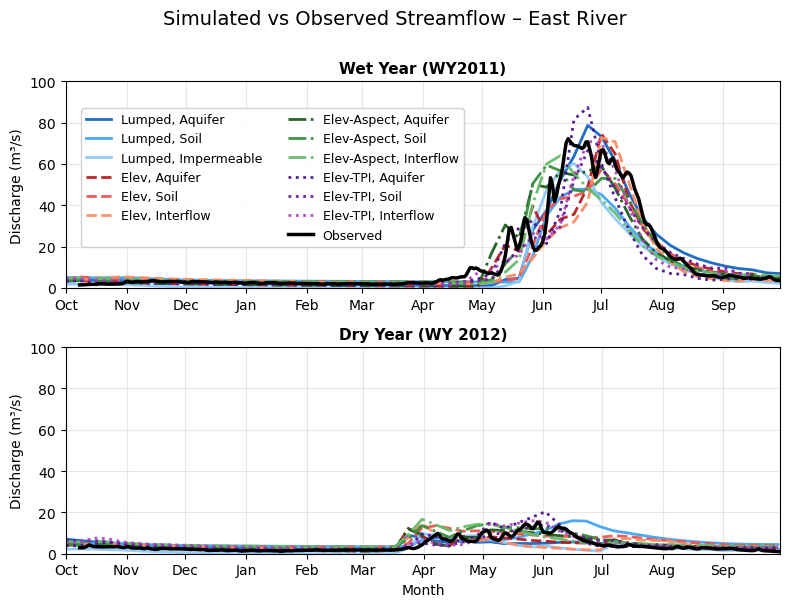

In [11]:
# import mdates
from matplotlib import dates as mdates
model_styles = {
    "lumped": {
        "bigBuckt":          {"color": "#1565C0", "ls": "-",  "label": "Lumped, Aquifer"},
        "noXplict_drainage": {"color": "#42A5F5", "ls": "-",  "label": "Lumped, Soil"},
        "noXplict_zeroFlux": {"color": "#90CAF9", "ls": "-",  "label": "Lumped, Impermeable"},
    },
    "distributed_elev": {
        "bigBuckt":          {"color": "#B71C1C", "ls": "--", "label": "Elev, Aquifer"},
        "noXplict_drainage": {"color": "#EF5350", "ls": "--", "label": "Elev, Soil"},
        "qTopmodl":          {"color": "#FF8A65", "ls": "--", "label": "Elev, Interflow"},
    },
    "distributed_elevAspect": {
        "bigBuckt":          {"color": "#1B5E20", "ls": "-.",  "label": "Elev-Aspect, Aquifer"},
        "noXplict_drainage": {"color": "#388E3C", "ls": "-.",  "label": "Elev-Aspect, Soil"},
        "qTopmodl":          {"color": "#66BB6A", "ls": "-.",  "label": "Elev-Aspect, Interflow"},
    },
    "distributed_elevTPI": {
        "noXplict_drainage": {"color": "#4A148C", "ls": ":",  "label": "Elev-TPI, Aquifer"},
        "bigBuckt":          {"color": "#6A1B9A", "ls": ":",  "label": "Elev-TPI, Soil"},
        "qTopmodl":          {"color": "#AB47BC", "ls": ":",  "label": "Elev-TPI, Interflow"},
    }
}

year_periods = [
    ("Wet Year (WY2011)",    WET_WY),
    # ("Normal Year (WY2016)", NORMAL_WY),
    ("Dry Year (WY 2012)",    DRY_WY),
]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=False)
fig.suptitle("Simulated vs Observed Streamflow – East River", fontsize=14, y=1.005)

for ax, (title, period) in zip(axes, year_periods):

    for domain, domain_styles in model_styles.items():
        for model_key, style in domain_styles.items():
            if model_key not in model_discharge.get(domain, {}):
                continue
            q_slice = model_discharge[domain][model_key].loc[period.start:period.stop].resample("7D").mean()
            if (period == WET_WY) & (domain == 'distributed_elevTPI'):
                shift = -2
            else:
                shift = 0
            ax.plot(q_slice.index, q_slice.shift(shift).values,
                    color=style['color'], linestyle=style['ls'],
                    linewidth=2, label=style['label'], alpha=0.95)
            if (domain == 'distributed_elev') and (model_key == 'qTopmodl'):
                print(True)
                ax.plot([],[], label=" ", lw=0)

    obs_slice = obs_streamflow['value'].loc[period.start:period.stop]
    ax.plot(obs_slice.index, obs_slice.shift(7).values,
                color='black', linewidth=2.5, label='Observed', zorder=10)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Discharge (m\u00b3/s)", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_xlim(pd.Timestamp(period.start), pd.Timestamp(period.stop))
    ax.set_ylim(0,100)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.1, 0.85),
           fontsize=9, framealpha=0.9, ncols=2)
axes[-1].set_xlabel("Month", fontsize=10)

plt.tight_layout()
fig.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_streamflow_wet_normal_dry.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import datetime as dt
# runoff metrics
def nse(obs, sim):
    obs_mean = np.mean(obs)
    numerator = np.sum((obs - sim) ** 2)
    denominator = np.sum((obs - obs_mean) ** 2)
    return 1 - (numerator / denominator)
def kge(obs, sim):
    obs_mean = np.mean(obs)
    sim_mean = np.mean(sim)
    obs_std = np.std(obs)
    sim_std = np.std(sim)
    correlation = np.corrcoef(obs, sim)[0, 1]
    alpha = sim_std / obs_std
    beta = sim_mean / obs_mean
    kge_value = 1 - np.sqrt((correlation - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    return kge_value
def log_nse(obs, sim):
    obs_log = np.log(obs + 1e-6)
    sim_log = np.log(sim + 1e-6)
    return nse(obs_log, sim_log)
def com_difference(obs, sim):
    # calculate average center of mass timing difference between obs and sim
    com_differences = []
    for wy in obs.index.year.unique():
        if wy == 2000:
            continue
        time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
        obs_wy = obs.loc[time_slice]
        sim_wy = sim.loc[time_slice]
        if obs_wy.empty or sim_wy.empty or obs_wy.sum() == 0 or sim_wy.sum() == 0:
            continue
        # center of mass timing
        com_obs = obs_wy.cumsum() / obs_wy.sum()
        com_sim = sim_wy.cumsum() / sim_wy.sum()
        above_half_obs = com_obs[com_obs >= 0.5]
        above_half_sim = com_sim[com_sim >= 0.5]
        if above_half_obs.empty or above_half_sim.empty:
            continue
        half_mass_obs = above_half_obs.index[0]   # add 1 day to get the first day above 50%
        half_mass_sim = above_half_sim.index[0] 
        com_differences.append(dt.timedelta(days=(half_mass_sim - half_mass_obs).days))
    mean_com_diff = np.mean(com_differences[1:])
    # convert to pandas timestamp
    mean_com_diff = pd.to_timedelta(mean_com_diff).days
    return mean_com_diff
def volume_normalized_bias(obs, sim):
    volume_bias = np.sum(sim - obs) / np.sum(obs)
    return volume_bias
def jas_volumetric_bias(obs, sim):
    jas_mask = obs.index.month.isin([7, 8, 9])
    obs_jas = obs[jas_mask]
    sim_jas = sim[jas_mask]
    jas_bias = np.sum(sim_jas - obs_jas) / np.sum(obs_jas)  
    return jas_bias

In [13]:
# build table for each model type of these metrics for all years
metric_df = pd.DataFrame(columns=['Domain', 'Model', 'NSE', 'KGE', 'Log NSE', 'COM Difference', 'Volume-Percent Total Bias', 'JAS Volume-Percent Bias'])
count = 0
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        obs = obs_streamflow['value'].loc[sim.index]
        mask = ~obs.isna() & ~sim.isna()
        nse_val = nse(obs[mask], sim[mask])
        kge_val = kge(obs[mask], sim[mask])
        log_nse_val = log_nse(obs[mask], sim[mask])
        com_diff_val = com_difference(obs[mask].iloc[1:], sim[mask].iloc[1:])
        vnb = volume_normalized_bias(obs[mask], sim[mask])
        jas_bias = jas_volumetric_bias(obs[mask], sim[mask])

        tmp_df = pd.DataFrame({
            'Domain': [domain],
            'Model': [model_key],
            'NSE': [nse_val],
            'KGE': [kge_val],
            'Log NSE': [log_nse_val],
            'COM Difference': [com_diff_val],
            'Normalized Volume Bias': [vnb],
            'JAS Volume-Percent Bias': [jas_bias]
        })
        if count == 0:
            metric_df = tmp_df
            count += 1
        else:
            metric_df = pd.concat([metric_df, tmp_df], ignore_index=True)

In [14]:
# get volume percent bias for each year
yearly_bias_df = pd.DataFrame(columns=['Domain', 'Model', 'Year', 'Volume-Percent Total Bias'])
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        for wy in obs_streamflow.index.year.unique():
            if wy < 2001:
                continue
            time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
            obs_wy = obs_streamflow['value'].where(mask).loc[time_slice]
            sim_wy = sim.where(mask).loc[time_slice]
            if obs_wy.empty or sim_wy.empty:
                continue
            vptb = volume_normalized_bias(obs_wy, sim_wy)
            yearly_bias_df = pd.concat([yearly_bias_df, pd.DataFrame({
                'Domain': [domain],
                'Model': [model_key],
                'Year': [wy],
                'Normalized Volume Bias': [vptb],
            })], ignore_index=True)

In [15]:
# order by noXplict_zeroFlux, noXplict_drainage, bigBuckt, qTopmodl
yearly_bias_df = yearly_bias_df.sort_values(by=['Domain', 'Model'], key=lambda col: col.map({
    "noXplict_zeroFlux": 0,
    "noXplict_drainage": 1,
    "bigBuckt": 2,
    "qTopmodl": 3
}))

(-0.45, 0.45)

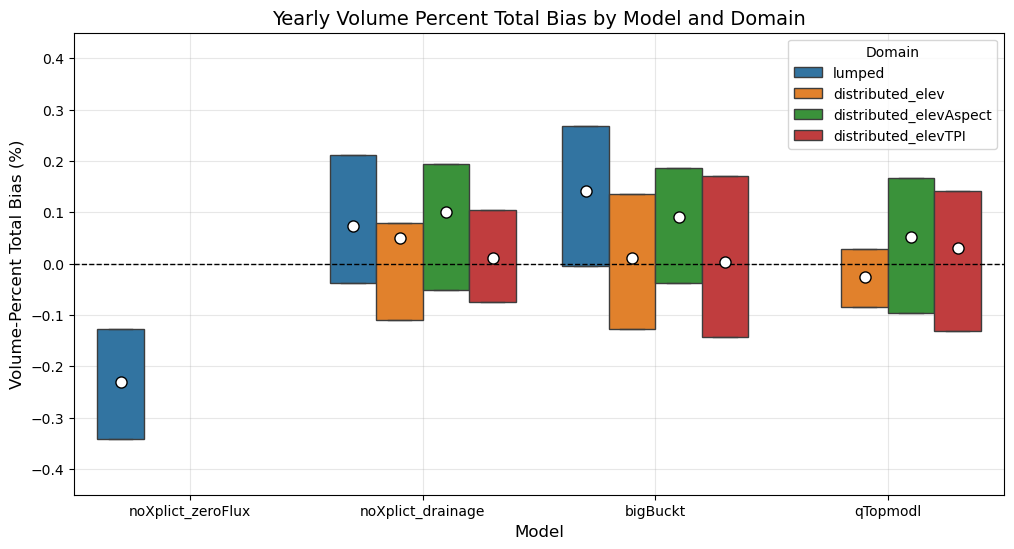

In [16]:
# plot boxplot of each models volume percent bias by year
plt.figure(figsize=(12, 6))
sns.boxplot(data=yearly_bias_df, 
            x='Model', 
            y='Normalized Volume Bias', 
            hue='Domain', showmeans=True,
            medianprops={'linewidth':0},
            meanprops={
                "marker": "o",          # Change shape (e.g., 'o' for circle, 's' for square)
                "markerfacecolor": "white", 
                "markeredgecolor": "black",
                "markersize": "8"
            },
            whis=0,
            showfliers=False,
            )
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Yearly Volume Percent Total Bias by Model and Domain", fontsize=14)
plt.ylabel("Volume-Percent Total Bias (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.legend(title='Domain')
plt.grid(True, alpha=0.3)
plt.ylim(-0.45, 0.45)

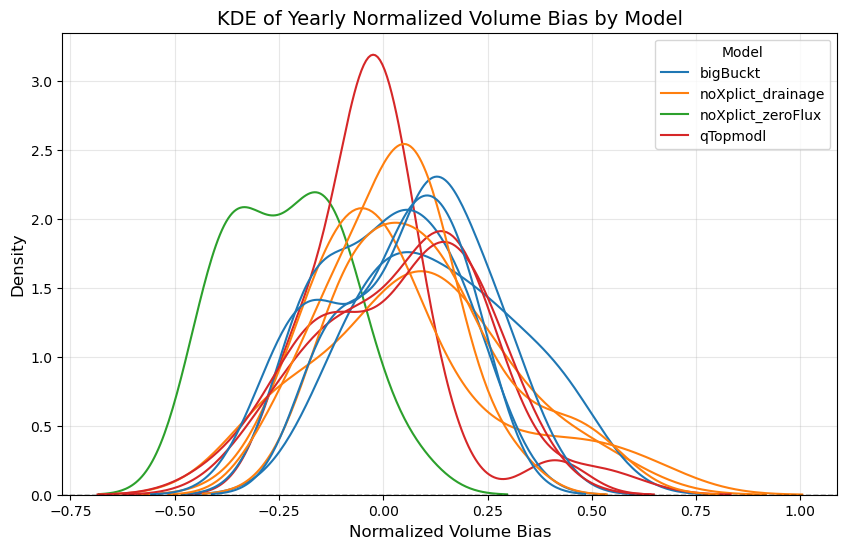

In [17]:
# create pdf of normal total flow bias, only show kde for all model types, make linestyle differentfor each domain
plt.figure(figsize=(10, 6))
for domain in yearly_bias_df['Domain'].unique():
    domain_data = yearly_bias_df[yearly_bias_df['Domain'] == domain]
    sns.kdeplot(data=domain_data, x='Normalized Volume Bias', hue='Model', fill=False, common_norm=False, alpha=1.0, linestyle='-',
                hue_order=['bigBuckt', 'noXplict_drainage', 'noXplict_zeroFlux', 'qTopmodl'])
plt.title("KDE of Yearly Normalized Volume Bias by Model", fontsize=14)
plt.xlabel("Normalized Volume Bias", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

/tmp/ipykernel_1733132/2912748552.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


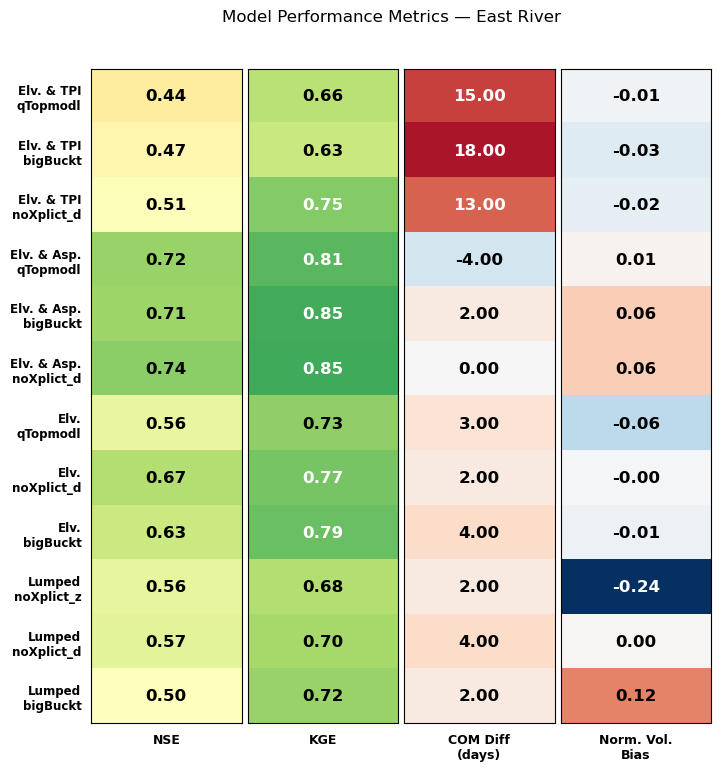

In [18]:

# --- Plot 1: per-column heatmap (visual table) ---
import matplotlib.colors as mcolors

domain_short = {
    'lumped': 'Lumped',
    'distributed_elev': 'Elv.',
    'distributed_elevAspect': 'Elv. & Asp.',
    'distributed_elevTPI': 'Elv. & TPI',
}
model_short = {
    'noXplict_zeroFlux': 'noXplict_z',
    'noXplict_drainage': 'noXplict_d',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
row_labels = [
    f"{domain_short[d]}\n{model_short[m]}"
    for d, m in zip(metric_df['Domain'], metric_df['Model'])
]

metrics_hmap = [
    ('NSE',                     'RdYlGn', False),
    ('KGE',                     'RdYlGn', False),
    ('COM Difference',          'RdBu_r',  True),
    ('Normalized Volume Bias',  'RdBu_r',  True),
]
col_display = ['NSE', 'KGE', 'COM Diff\n(days)', 'Norm. Vol.\nBias']

fig, axes = plt.subplots(1, 4, figsize=(8, 8.5), sharey=True,
                         gridspec_kw={'wspace': 0.04})

for ax, (col, cmap, diverging), xlabel in zip(axes, metrics_hmap, col_display):
    vals = metric_df[col].values[::-1]
    data = vals.reshape(-1, 1)

    if diverging:
        if col == 'COM Difference':
            offset = 4
        else: offset = 0.1
        absmax = max(abs(vals.min()), abs(vals.max())+offset, 1e-9)
        norm = mcolors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
    else:
        norm = mcolors.Normalize(vmin=min(vals.min(), 0), vmax=1.0)

    im = ax.imshow(data, cmap=cmap, norm=norm, aspect='auto')

    for i, v in enumerate(vals):
        brightness = norm(v)
        txt_color = 'white' if (brightness < 0.25 or brightness > 0.75) else 'black'
        ax.text(0, i, f'{v:.2f}', ha='center', va='center',
                fontsize=12, color=txt_color, fontweight='bold')

    ax.set_xticks([0])
    ax.set_xticklabels([xlabel], rotation=0, ha='center', fontsize=9, fontweight='bold')
    ax.tick_params(left=False, bottom=False)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(ax.get_yticks(), fontweight='bold')

axes[0].set_yticklabels(row_labels[::-1], fontsize=8.5)
# for ax in axes[1:]:
#     ax.set_yticklabels([])

fig.suptitle("Model Performance Metrics — East River", fontsize=12, y=0.95)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_metrics_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()


[Text(0, 0.5, 'Elev-TPI'),
 Text(0, 1.5, 'Elev-Aspect'),
 Text(0, 2.5, 'Elev'),
 Text(0, 3.5, 'Lumped')]

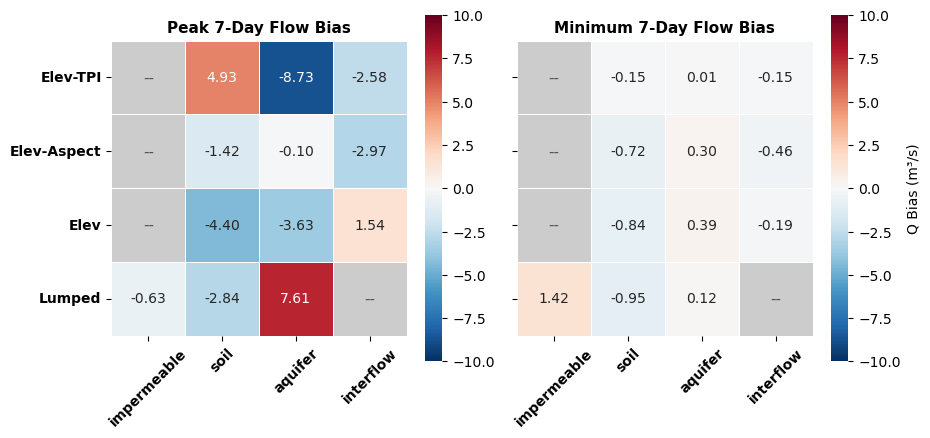

In [19]:
# --- Other performance metrics: peak 7D flow mean bias, minimum 7D flow mean bias, as a table with heatmap coloring ---
def peak_7d_bias(obs, sim):
    obs_7d = obs.rolling(window=10).mean()
    sim_7d = sim.rolling(window=7).mean()
    # idenetify peaks for each year
    obs_peaks = obs_7d.groupby(obs_7d.index.year).max()
    sim_peaks = sim_7d.groupby(sim_7d.index.year).max()
    bias = np.mean((sim_peaks - obs_peaks))
    return bias
def min_7d_bias(obs, sim):
    obs_7d = obs.rolling(window=7).mean()
    sim_7d = sim.rolling(window=7).mean()
    # idenetify peaks for each year
    obs_min = obs_7d.groupby(obs_7d.index.year).min()
    sim_min = sim_7d.groupby(sim_7d.index.year).min()
    bias = np.mean((obs_min - sim_min))
    return bias
peak_and_min = []
for idx, row in metric_df.iterrows():
    domain = row['Domain']
    model = row['Model']
    sim = model_discharge[domain][model]
    obs = obs_streamflow['value'].loc[sim.index]
    mask = ~obs.isna() & ~sim.isna()
    peak_7d = peak_7d_bias(obs[mask], sim[mask])
    min_7d = min_7d_bias(obs[mask], sim[mask])
    peak_and_min.append({'Domain': domain, 'Model': model, 'Peak 7D Bias': peak_7d, 'Min 7D Bias': min_7d})

peak_and_min_df = pd.DataFrame(peak_and_min)
peak_and_min_df = peak_and_min_df.sort_values(by=['Domain', 'Model'], key=lambda col: col.map({
    "noXplict_zeroFlux": 0,
    "noXplict_drainage": 1,
    "bigBuckt": 2,
    "qTopmodl": 3
}))
pivot_peak = peak_and_min_df.pivot(index='Domain', columns='Model', values='Peak 7D Bias')
pivot_min = peak_and_min_df.pivot(index='Domain', columns='Model', values='Min 7D Bias')

# order by zeroFlux, drainage, bigBuckt, qTopmodl
model_order = ['noXplict_zeroFlux', 'noXplict_drainage', 'bigBuckt', 'qTopmodl']
renames = ['impermeable', 'soil', 'aquifer', 'interflow']
domain_order = ['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI'][::-1]
domain_renames = ['Lumped', 'Elev', 'Elev-Aspect', 'Elev-TPI'][::-1]
pivot_peak = pivot_peak[model_order].loc[domain_order]
pivot_peak.index = domain_renames
pivot_min = pivot_min[model_order].loc[domain_order]
pivot_min.index = domain_renames

# rename columns
pivot_peak.columns = renames
pivot_min.columns = renames

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True,
                         gridspec_kw={'wspace': 0.1})
nan_mask = pivot_peak.isna()

ax = axes[0]
sns.heatmap(
    pivot_peak,
    mask=nan_mask,          # hide NaN from colormap (shows facecolor instead)
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-10,
    vmax=10,
    linewidths=0.5,         # lines between cells
    linecolor='white',      # line color
    square=True,
    cbar_kws={'label': None, "shrink": 0.75},
    ax=ax
)

ax.set_facecolor('#cccccc')  # grey shows through where mask=True

# Overlay "--" text on NaN cells
for i in range(pivot_peak.shape[0]):
    for j in range(pivot_peak.shape[1]):
        if nan_mask.iloc[i, j]:
            ax.text(j + 0.5, i + 0.5, '--', ha='center', va='center',
                    fontsize=11, color='#555555')

ax = axes[1]
sns.heatmap(
    pivot_min,
    mask=nan_mask,          # hide NaN from colormap (shows facecolor instead)
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-10,
    vmax=10,
    linewidths=0.5,         # lines between cells
    linecolor='white',      # line color
    square=True,
    cbar_kws={'label': 'Q Bias (m³/s)', "shrink": 0.75},
    ax=ax
)

ax.set_facecolor('#cccccc')  # grey shows through where mask=True

# Overlay "--" text on NaN cells
for i in range(pivot_min.shape[0]):
    for j in range(pivot_min.shape[1]):
        if nan_mask.iloc[i, j]:
            ax.text(j + 0.5, i + 0.5, '--', ha='center', va='center',
                    fontsize=11, color='#555555')

axes[0].set_title("Peak 7-Day Flow Bias", fontsize=11, fontweight='bold')
axes[1].set_title("Minimum 7-Day Flow Bias", fontsize=11, fontweight='bold')
axes[0].set_xticklabels(pivot_peak.columns, rotation=45, ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticklabels(pivot_min.columns, rotation=45, ha='center', fontsize=10, fontweight='bold')
axes[0].set_yticklabels(pivot_peak.index, fontsize=10, fontweight='bold', rotation=0)

10 [0.76580106 0.998102  ]
11 [-0.67727361  0.62237458]
10 [ 0.79430749 -0.04168402]
11 [ 0.22529233 -0.23110795]


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


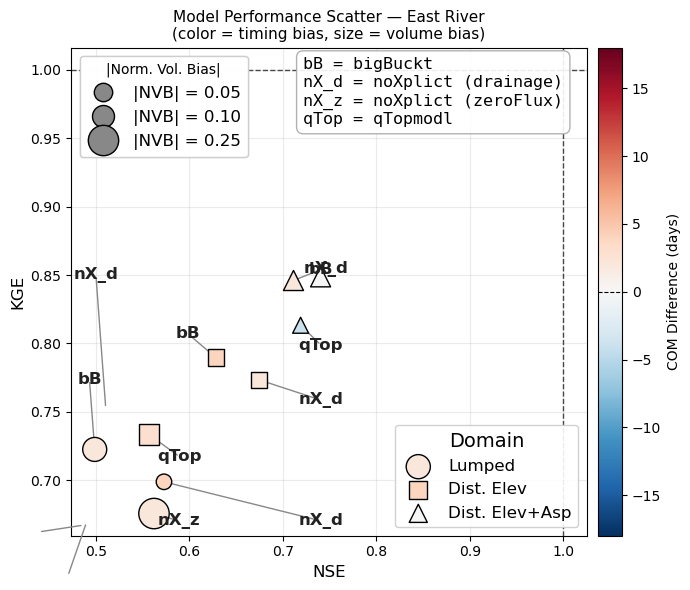

In [20]:

# --- Plot 2: performance scatter (Taylor-diagram-like) ---
from matplotlib.lines import Line2D
from adjustText import adjust_text

domain_markers = {
    'lumped':                 ('o', 'Lumped'),
    'distributed_elev':       ('s', 'Dist. Elev'),
    'distributed_elevAspect': ('^', 'Dist. Elev+Asp'),
}
model_abbrev = {
    'bigBuckt':          'bB',
    'noXplict_drainage': 'nX_d',
    'noXplict_zeroFlux': 'nX_z',
    'qTopmodl':          'qTop',
}
model_fullname = {
    'bB':    'bigBuckt',
    'nX_d':  'noXplict (drainage)',
    'nX_z':  'noXplict (zeroFlux)',
    'qTop':  'qTopmodl',
}

com  = metric_df['COM Difference'].values
nvb  = metric_df['Normalized Volume Bias'].values
nse_ = metric_df['NSE'].values
kge_ = metric_df['KGE'].values

absmax_com = max(abs(com.min()), abs(com.max()), 1)
com_norm   = mcolors.TwoSlopeNorm(vmin=-absmax_com, vcenter=0, vmax=absmax_com)
cmap_com   = plt.cm.RdBu_r

nvb_abs = np.abs(nvb)
sizes   = 120 + 360 * (nvb_abs / nvb_abs.max())

fig, ax = plt.subplots(figsize=(7, 6))

for domain, (marker, dlabel) in domain_markers.items():
    mask = (metric_df['Domain'] == domain).values
    ax.scatter(
        nse_[mask], kge_[mask],
        c=com[mask], cmap=cmap_com, norm=com_norm,
        s=sizes[mask], marker=marker,
        edgecolors='k', linewidths=1.0, zorder=5,
        label=dlabel,
    )

sm = plt.cm.ScalarMappable(cmap=cmap_com, norm=com_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label('COM Difference (days)', fontsize=10)
cbar.ax.axhline(0, color='k', lw=0.8, ls='--')

texts = []
for _, row in metric_df.iterrows():
    t = ax.annotate(
        model_abbrev[row['Model']],
        (row['NSE'], row['KGE']),
        fontsize=12, color='#222222', fontweight='bold',
        zorder=10,
    )
    texts.append(t)

adjust_text(
    texts, ax=ax, expand=(6.4, 6.7), ha='left', va='top',
    arrowprops=dict(arrowstyle='-', color='#888888', lw=1),
);

# domain legend (lower right)
domain_legend = ax.legend(title='Domain', fontsize=12, loc='lower right', framealpha=0.9, title_fontsize=14)
ax.add_artist(domain_legend);

# size legend for |NVB| (upper left)
nvb_refs  = [0.05, 0.10, 0.25]
size_refs = [100 + 360 * (v / nvb_abs.max()) for v in nvb_refs]
size_handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           color='w', markerfacecolor='#888888', markeredgecolor='k',
           markersize=np.sqrt(s), label=f'|NVB| = {v:.2f}')
    for v, s in zip(nvb_refs, size_refs)
]
size_legend = ax.legend(handles=size_handles, title='|Norm. Vol. Bias|',
                        fontsize=12, loc='upper left', framealpha=0.9)
ax.add_artist(size_legend)

# model abbreviation key (upper right, plain text box)
abbrev_lines = '\n'.join(f'{k} = {v}' for k, v in model_fullname.items())
ax.text(
    0.45, 0.98, abbrev_lines,
    transform=ax.transAxes,
    fontsize=12, va='top', ha='left', family='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#aaaaaa', alpha=0.9),
)

ax.axhline(1, color='k', ls='--', lw=1.0, alpha=0.7)
ax.axvline(1, color='k', ls='--', lw=1.0, alpha=0.7)
ax.set_xlabel('NSE', fontsize=12)
ax.set_ylabel('KGE', fontsize=12)
ax.set_title('Model Performance Scatter — East River\n'
             '(color = timing bias, size = volume bias)', fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_metrics_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()


## SWE - Q regression scatter

In [21]:
# get snotel data
snotel_df = pd.read_csv(DATA_DIR / f"domain_{DOMAIN}_distributed" / "observations" / "formatted" / "snotel_swe.csv", parse_dates=['date'], index_col='date')
snotel_apr1_swe = snotel_df[(snotel_df.index.month == 4) & (snotel_df.index.day == 1)]
snotel_apr1_swe.index = snotel_apr1_swe.index.year
annual_q = obs_streamflow.resample('AS-OCT').sum()  # Annual runoff (Oct 1 - Sep 30)
annual_q.index = annual_q.index.year+1
# SWE-Q runoff regression
swe_q_df = pd.DataFrame({
    'apr1_swe': snotel_apr1_swe['value'],
    'annual_q': annual_q['value']
})



/tmp/ipykernel_1733132/2094612696.py:5: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  annual_q = obs_streamflow.resample('AS-OCT').sum()  # Annual runoff (Oct 1 - Sep 30)


In [22]:
# get mean, daily scalarSWE from each model
swe_daily_dict = {}
for domain, models in model_discharge.items():
    # hru area
    
    for model_key, sim in models.items():
        filepath = model_files[domain][model_key]
        hru_area = xr.open_dataset(attr_paths[domain])['HRUarea']
        ds = xr.open_dataset(filepath)
        if 'scalarSWE' in ds.data_vars:
            swe_var = (ds['scalarSWE']*hru_area).sum(dim='hru')/area_m2
            # for each year, get 1 Apr SWE
            swe_apr1 = []
            wys = []
            for wy in sim.index.year.unique():
                if (wy < 2001) or (wy > 2021):
                    continue
                wys.append(wy)
                time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
                swe_wy = swe_var.sel(time=time_slice)
                # get 1 Apr value
                apr1 = pd.Timestamp(f"{wy}-04-01")
                if apr1 in swe_wy.time.values:
                    swe_apr1.append(float(swe_wy.sel(time=apr1).values))
                else:
                    # if no exact match, interpolate
                    swe_apr1.append(float(swe_wy.interp(time=apr1).values))
            swe_daily_dict[(domain, model_key)] = pd.DataFrame({
                'apr1_swe': swe_apr1,
            }, index=wys)



In [23]:
# calculate water year annual q for each model
annual_q_dict = {}
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        wy_q = []
        wys = []
        for wy in sim.index.year.unique():
            if (wy < 2001) or (wy > 2021):
                continue
            time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
            sim_wy = sim.loc[time_slice]
            annual_q = sim_wy.sum()
            wy_q.append(annual_q)
            wys.append(wy)

        annual_q_dict[(domain, model_key)] = pd.DataFrame({
            'annual_q': wy_q,
        }, index=wys)

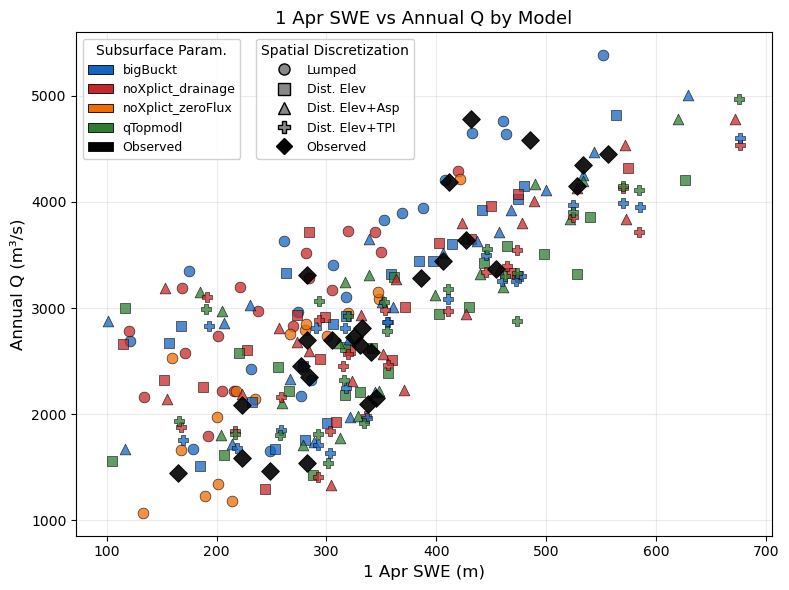

In [24]:
# scatter plot of 1 Apr SWE vs annual Q — color = model type, shape = domain
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_colors = {
    'bigBuckt':          '#1565C0',
    'noXplict_drainage': '#C62828',
    'noXplict_zeroFlux': '#EF6C00',
    'qTopmodl':          '#2E7D32',
}
domain_markers = {
    'lumped':                 'o',
    'distributed_elev':       's',
    'distributed_elevAspect': '^',
    'distributed_elevTPI':    'P',
}
domain_labels = {
    'lumped':                 'Lumped',
    'distributed_elev':       'Dist. Elev',
    'distributed_elevAspect': 'Dist. Elev+Asp',
    'distributed_elevTPI':    'Dist. Elev+TPI',
}

fig, ax = plt.subplots(figsize=(8, 6))

for (domain, model_key), swe_df in swe_daily_dict.items():
    annual_q = annual_q_dict[(domain, model_key)]
    merged_df = swe_df.merge(annual_q, left_index=True, right_index=True)
    merged_df = merged_df[merged_df['apr1_swe']>100]
    ax.scatter(
        merged_df['apr1_swe'], merged_df['annual_q'],
        color=model_colors[model_key],
        marker=domain_markers[domain],
        alpha=0.75, edgecolors='k', linewidths=0.5, s=60, zorder=4,
    )

# observed
ax.scatter(
    swe_q_df['apr1_swe'], swe_q_df['annual_q'],
    color='black', marker='D', s=80, edgecolors='k', linewidths=0.8,
    alpha=0.9, zorder=5,
)

# color legend — model type (upper left)
model_keys_present = {mk for _, mk in swe_daily_dict.keys()}
color_handles = [
    Patch(facecolor=c, edgecolor='k', linewidth=0.6, label=m)
    for m, c in model_colors.items() if m in model_keys_present
]
color_handles.append(Patch(facecolor='black', edgecolor='k', linewidth=0.6, label='Observed'))
color_legend = ax.legend(handles=color_handles, title='Subsurface Param.',
                         fontsize=9, loc='upper left', framealpha=0.9)
ax.add_artist(color_legend)

# shape legend — domain (lower right)
domains_present = {d for d, _ in swe_daily_dict.keys()}
shape_handles = [
    Line2D([0], [0], marker=m, linestyle='None', color='w',
           markerfacecolor='#888888', markeredgecolor='k',
           markersize=8, label=domain_labels[d])
    for d, m in domain_markers.items() if d in domains_present
]
shape_handles.append(
    Line2D([0], [0], marker='D', linestyle='None', color='w',
           markerfacecolor='black', markeredgecolor='k',
           markersize=8, label='Observed')
)
ax.legend(handles=shape_handles, title='Spatial Discretization', fontsize=9,
          loc='upper left', framealpha=0.9, bbox_to_anchor=(0.25, 1))

ax.set_xlabel('1 Apr SWE (m)', fontsize=12)
ax.set_ylabel('Annual Q (m³/s)', fontsize=12)
ax.set_title('1 Apr SWE vs Annual Q by Model', fontsize=13)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [25]:
# SWE-Q regressions for each model type
from sklearn.linear_model import LinearRegression
regression_results = []
for (domain, model_key), swe_df in swe_daily_dict.items():
    annual_q = annual_q_dict[(domain, model_key)]
    merged_df = swe_df.merge(annual_q, left_index=True, right_index=True).dropna()
    merged_df = merged_df[(merged_df['apr1_swe'] >= 150) & (merged_df['annual_q'] >= 0)]
    X = merged_df['apr1_swe'].values.reshape(-1, 1)
    y = merged_df['annual_q'].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)
    regression_results.append({
        'Domain': domain,
        'Model': model_key,
        'Slope': reg.coef_[0],
        'Intercept': reg.intercept_,
        'R²': r2,
    })
obs_regression = LinearRegression().fit(swe_q_df.dropna()['apr1_swe'].values.reshape(-1, 1), swe_q_df.dropna()['annual_q'].values)
regression_results.append({
    'Domain': 'Observed',
    'Model': 'Observed',
    'Slope': obs_regression.coef_[0],
    'Intercept': obs_regression.intercept_,
    'R²': obs_regression.score(swe_q_df.dropna()['apr1_swe'].values.reshape(-1, 1), swe_q_df.dropna()['annual_q'].values),
})


## SWE-Q regression diagnostrics across model types. 

In [26]:
# # SWE-Q regression diagnostic scatter
# # x = Pearson r, y = slope (sensitivity), color = R²
# # shape = domain, observed shown as black diamond

# reg_df = pd.DataFrame(regression_results)
# reg_df['r'] = np.sqrt(reg_df['R²'])   # r = sqrt(R²) for positive-slope OLS

# domain_markers_reg = {
    
#     'lumped':                 'o',
#     'distributed_elev':       's',
#     'distributed_elevAspect': '^',
#     'distributed_elevTPI':    'P',
#     'Observed':               'D',
# }
# domain_labels_reg = {
#     'lumped':                 'Lumped',
#     'distributed_elev':       'Dist. Elev',
#     'distributed_elevAspect': 'Dist. Elev+Asp',
#     'distributed_elevTPI':    'Dist. Elev+TPI',
#     'Observed':               'Observed',
# }
# model_abbrev_reg = {
#     'bigBuckt':          'bB',
#     'noXplict_drainage': 'nX_d',
#     'noXplict_zeroFlux': 'nX_z',
#     'qTopmodl':          'qTop',
#     'Observed':          'Obs',
# }

# r2_vals    = reg_df['R²'].values
# slope_vals = reg_df['Slope'].values
# r2_norm    = mcolors.Normalize(vmin=0, vmax=1)
# cmap_r2    = plt.cm.YlOrRd

# fig, ax = plt.subplots(figsize=(7, 6))

# # model points
# for _, row in reg_df[reg_df['Domain'] != 'Observed'].iterrows():
#     ax.scatter(
#         row['r'], row['Slope'],
#         c=[cmap_r2(r2_norm(row['R²']))],
#         marker=domain_markers_reg[row['Domain']],
#         s=100, edgecolors='k', linewidths=0.8, zorder=5,
#     )

# # observed — always black diamond, still colored by R²
# obs_row = reg_df[reg_df['Domain'] == 'Observed'].iloc[0]
# ax.scatter(
#     obs_row['r'], obs_row['Slope'],
#     c=[cmap_r2(r2_norm(obs_row['R²']))],
#     marker='D', s=130, edgecolors='k', linewidths=1.5, zorder=6,
# )

# # colorbar for R²
# sm = plt.cm.ScalarMappable(cmap=cmap_r2, norm=r2_norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
# cbar.set_label('R²', fontsize=11)

# # labels
# texts = []
# for _, row in reg_df.iterrows():
#     t = ax.annotate(
#         model_abbrev_reg.get(row['Model'], row['Model']),
#         (row['r'], row['Slope']),
#         fontsize=8.5, fontweight='bold', color='#222222', zorder=10,
#     )
#     texts.append(t)
# adjust_text(texts, ax=ax, expand=(1.4, 1.6),
#             arrowprops=dict(arrowstyle='-', color='#888888', lw=0.7))

# # observed reference lines
# ax.axhline(obs_row['Slope'], color='k', ls='--', lw=0.8, alpha=0.5, label='_')
# ax.axvline(obs_row['r'],     color='k', ls='--', lw=0.8, alpha=0.5, label='_')

# # shape legend
# domains_in_reg = set(reg_df['Domain'].unique())
# shape_handles = [
#     Line2D([0],[0], marker=domain_markers_reg[d], linestyle='None', color='w',
#            markerfacecolor='#888888', markeredgecolor='k',
#            markersize=8, label=domain_labels_reg[d])
#     for d in domain_markers_reg if d in domains_in_reg
# ]
# ax.legend(handles=shape_handles, title='Domain', fontsize=9,
#           loc='lower right', framealpha=0.9)

# ax.set_xlabel('Pearson r  (SWE–Q correlation)', fontsize=11)
# ax.set_ylabel('Slope  (m³/s per m SWE)', fontsize=11)
# # ax.set_title('SWE–Q Regression by Model', color = R², dashed lines = observed reference)', fontsize=11)
# ax.grid(True, alpha=0.25)
# plt.tight_layout()
# # plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_sweQ_regression_scatter.png',
# #             dpi=150, bbox_inches='tight')
# plt.show()

## Observed v. Modeled streamflow with model spread

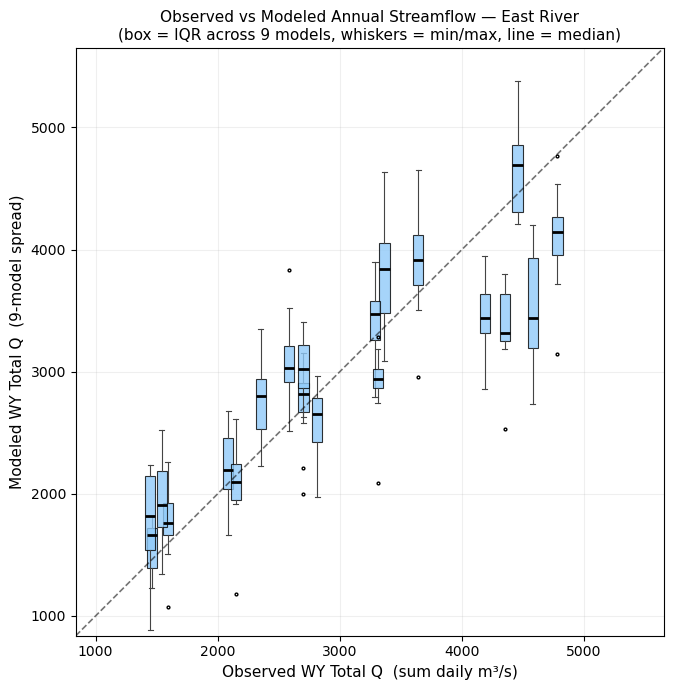

In [27]:
# Boxplot: for each WY, show spread of 9 modeled Q values
# box positioned at observed Q on x-axis, y centered on median

obs_wy_totals = {}
for wy in range(2002, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_wy_totals[wy] = obs_wy.sum()
obs_wy_series = pd.Series(obs_wy_totals)

box_positions, box_data, box_years = [], [], []
for wy, obs_q in sorted(obs_wy_series.items()):
    model_vals = [
        sim_df.loc[wy, 'annual_q']
        for (_, _), sim_df in annual_q_dict.items()
        if wy in sim_df.index
    ]
    if model_vals:
        box_positions.append(obs_q)
        box_data.append(model_vals)
        box_years.append(wy)

q_range   = max(box_positions) - min(box_positions)
box_width = q_range * 0.025

fig, ax = plt.subplots(figsize=(8, 7))

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=box_width,
    patch_artist=True,
    vert=True,
    manage_ticks=False,
    medianprops=dict(color='black',    linewidth=2.0),
    boxprops=dict(facecolor='#90CAF9', alpha=0.8, linewidth=0.8),
    whiskerprops=dict(linewidth=0.8,   color='#444'),
    capprops=dict(linewidth=0.8,       color='#444'),
    flierprops=dict(marker='.', markersize=4, color='#666'),
)

# annotate each box with the water year at the median


# 1:1 line
all_sim_flat = np.concatenate(box_data)
lim_lo = min(min(box_positions), all_sim_flat.min()) * 0.95
lim_hi = max(max(box_positions), all_sim_flat.max()) * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1.2, alpha=0.55, zorder=2)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_aspect('equal')

ax.set_xlabel('Observed WY Total Q  (sum daily m³/s)', fontsize=11)
ax.set_ylabel('Modeled WY Total Q  (9-model spread)', fontsize=11)
ax.set_title('Observed vs Modeled Annual Streamflow — East River\n'
             '(box = IQR across 9 models, whiskers = min/max, line = median)',
             fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_obs_vs_sim_annual_Q_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Observed v. Modeled SWE with model spread

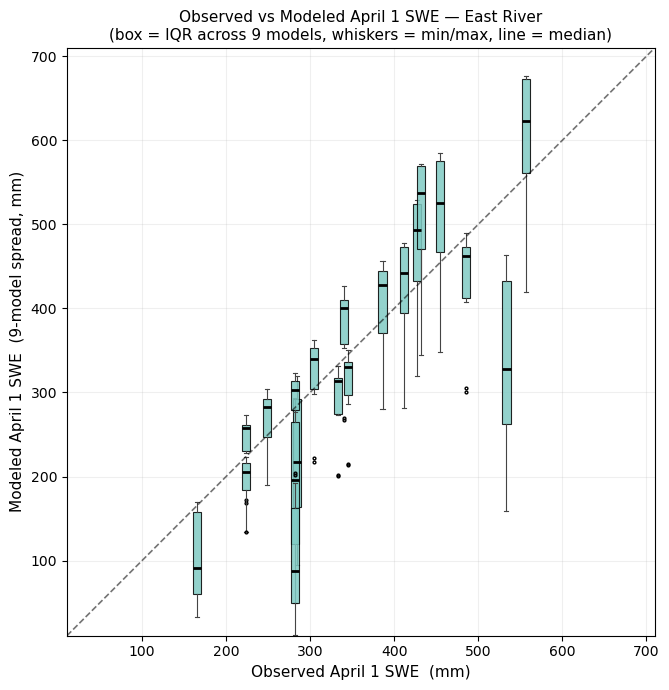

In [28]:
# Boxplot: April 1 SWE observed vs modeled (9-model spread per year)
# observed = SNOTEL (mm), modeled scalarSWE converted m→mm
# years with observed Apr1 SWE < 100 mm excluded

obs_apr1 = snotel_apr1_swe['value'].copy()   # mm, indexed by year
obs_apr1 = obs_apr1[obs_apr1 >= 100]

box_positions, box_data, box_years = [], [], []
for wy, obs_swe in sorted(obs_apr1.items()):
    if wy < 2002 or wy > 2021:
        continue
    model_vals = [
        swe_df.loc[wy, 'apr1_swe']   # m → mm
        for (_, _), swe_df in swe_daily_dict.items()
        if wy in swe_df.index
    ]
    if model_vals:
        box_positions.append(obs_swe)
        box_data.append(model_vals)
        box_years.append(wy)

q_range   = max(box_positions) - min(box_positions)
box_width = q_range * 0.025

fig, ax = plt.subplots(figsize=(8, 7))

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=box_width,
    patch_artist=True,
    vert=True,
    manage_ticks=False,
    medianprops=dict(color='black',    linewidth=2.0),
    boxprops=dict(facecolor='#80CBC4', alpha=0.85, linewidth=0.8),
    whiskerprops=dict(linewidth=0.8,   color='#444'),
    capprops=dict(linewidth=0.8,       color='#444'),
    flierprops=dict(marker='.', markersize=4, color='#666'),
)

all_sim_flat = np.concatenate(box_data)
lim_lo = min(min(box_positions), all_sim_flat.min()) * 0.9
lim_hi = max(max(box_positions), all_sim_flat.max()) * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1.2, alpha=0.55, zorder=2)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_aspect('equal')

ax.set_xlabel('Observed April 1 SWE  (mm)', fontsize=11)
ax.set_ylabel('Modeled April 1 SWE  (9-model spread, mm)', fontsize=11)
ax.set_title('Observed vs Modeled April 1 SWE — East River\n'
             '(box = IQR across 9 models, whiskers = min/max, line = median)',
             fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_obs_vs_sim_apr1SWE_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Runoff ratio boxplots

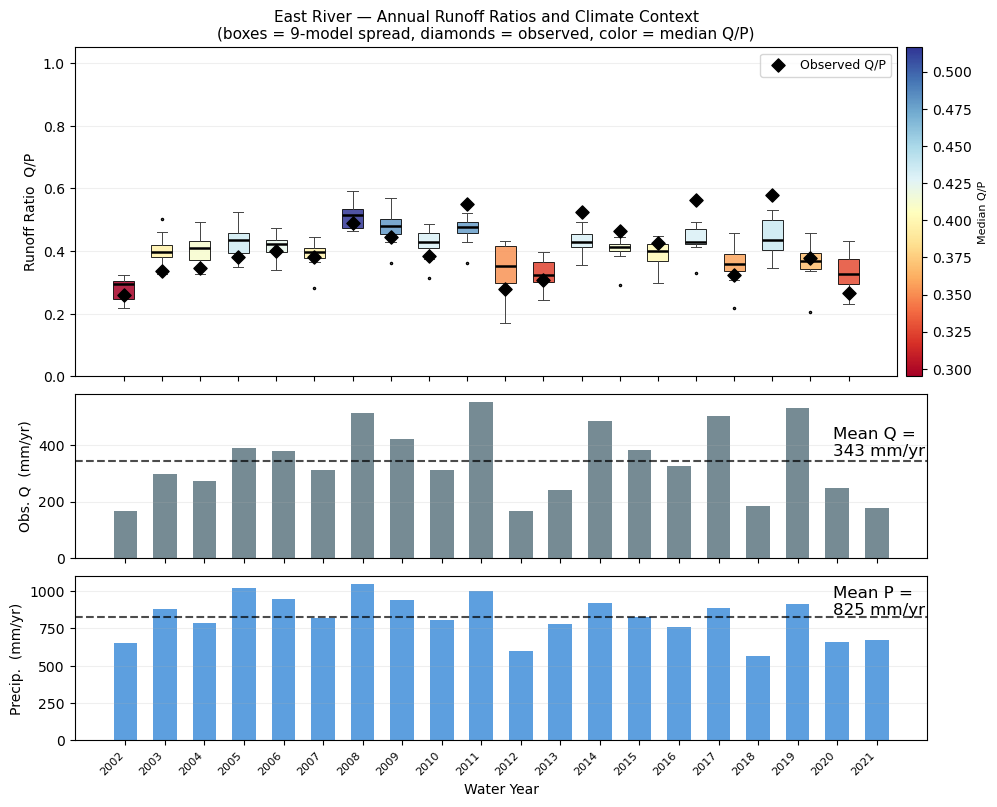

In [29]:
# Runoff ratio (Q/P) by water year
# Q converted to depth (mm/yr), P from pptrate (kg m-2 s-1 -> mm/yr)
# Three panels: Q/P boxplot (models) | observed Q | annual P
# Boxes colored by median Q/P value

import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Precipitation: use pptrate from lumped bigBuckt output (same ERA5 for all) ---
ds_p = xr.open_dataset(model_files['lumped']['bigBuckt'])
area_lump = domain_areas['lumped']
p_rate = ds_p['pptrate'].squeeze()                        # kg m-2 s-1
p_daily = (p_rate * 86400).resample(time='1D').mean()    # mm/day

precip_wy = {}
for wy in range(2002, 2022):
    p_wy = p_daily.sel(time=slice(f"{wy-1}-10-01", f"{wy}-09-30"))
    if len(p_wy) > 0:
        precip_wy[wy] = float(p_wy.sum())
precip_series = pd.Series(precip_wy)

# --- Observed Q in depth (mm/yr) ---
obs_q_mm = {}
for wy in range(2002, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_q_mm[wy] = obs_wy.sum() * 86400 / area_lump * 1000  # m3/s -> mm/yr
obs_q_mm = pd.Series(obs_q_mm)

# --- Modeled Q in depth (mm/yr) per model, aligned to same domain area ---
rr_box_data, rr_years = [], []
for wy in sorted(precip_series.index):
    if wy not in obs_q_mm.index:
        continue
    p_mm = precip_series[wy]
    model_rr = []
    for (domain, model_key), sim_df in annual_q_dict.items():
        if wy not in sim_df.index:
            continue
        area = domain_areas[domain]
        q_mm = sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000
        model_rr.append(q_mm / p_mm)
    if model_rr:
        rr_box_data.append(model_rr)
        rr_years.append(wy)

obs_rr = obs_q_mm / precip_series
obs_rr = obs_rr.dropna()

# --- Color boxes by median RR (low=dry orange, high=wet blue) ---
medians     = np.array([np.median(d) for d in rr_box_data])
rr_norm     = mcolors.Normalize(vmin=medians.min(), vmax=medians.max())
rr_cmap     = cm.RdYlBu
box_colors  = [rr_cmap(rr_norm(m)) for m in medians]

# --- Figure: 3 panels sharing x-axis ---
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={'hspace': 0.08, 'height_ratios': [2, 1, 1]})

# --- Panel 1: Q/P boxplots ---
ax1 = axes[0]
x = np.arange(len(rr_years))
for i, (data, color) in enumerate(zip(rr_box_data, box_colors)):
    bp = ax1.boxplot(
        data, positions=[x[i]], widths=0.55,
        patch_artist=True, vert=True, manage_ticks=False,
        medianprops=dict(color='black', linewidth=1.8),
        boxprops=dict(facecolor=color, alpha=0.85, linewidth=0.7),
        whiskerprops=dict(linewidth=0.7, color='#444'),
        capprops=dict(linewidth=0.7, color='#444'),
        flierprops=dict(marker='.', markersize=3, color='#777'),
    )

# observed Q/P overlay
obs_x = [x[rr_years.index(wy)] for wy in obs_rr.index if wy in rr_years]
ax1.scatter(obs_x, obs_rr.loc[[wy for wy in obs_rr.index if wy in rr_years]],
            color='black', marker='D', s=45, zorder=6, label='Observed Q/P')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_ylabel('Runoff Ratio  Q/P', fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.2, axis='y')

# colorbar for Q/P value
sm = cm.ScalarMappable(cmap=rr_cmap, norm=rr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax1, pad=0.01, fraction=0.025, aspect=20)
cbar.set_label('Median Q/P', fontsize=8)

# --- Panel 2: Observed Q (mm/yr) ---
ax2 = axes[1]
ax2.bar(x, obs_q_mm.loc[rr_years].values, color='#546E7A', alpha=0.8, width=0.6)
# plot the mean as a horizontal line
mean_q = obs_q_mm.loc[rr_years].mean()
ax2.axhline(y=mean_q, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
# annotate the line 
ax2.text(x[-1]-1.1, mean_q+65, f'Mean Q =\n{mean_q:.0f} mm/yr', va='center', ha='left', fontsize=12, color='black')
ax2.set_ylabel('Obs. Q  (mm/yr)', fontsize=10)
ax2.grid(True, alpha=0.2, axis='y')

# --- Panel 3: Annual precipitation (mm/yr) ---
ax3 = axes[2]
ax3.bar(x, precip_series.loc[rr_years].values, color='#1976D2', alpha=0.7, width=0.6)
# plot the mean as a horizontal line
mean_p = precip_series.loc[rr_years].mean()
ax3.axhline(y=mean_p, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.text(x[-1]-1.1, mean_p+105, f'Mean P =\n{mean_p:.0f} mm/yr', va='center', ha='left', fontsize=12, color='black')
ax3.set_ylabel('Precip.  (mm/yr)', fontsize=10)
ax3.grid(True, alpha=0.2, axis='y')

ax3.set_xticks(x)
ax3.set_xticklabels(rr_years, rotation=45, ha='right', fontsize=8)
ax3.set_xlabel('Water Year', fontsize=10)

axes[0].set_title('East River — Annual Runoff Ratios and Climate Context\n'
                  '(boxes = 9-model spread, diamonds = observed, color = median Q/P)',
                  fontsize=11)

plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_runoff_ratio_wy.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Spaghetti plot of runoff ratio
Includes SWE-Q regression

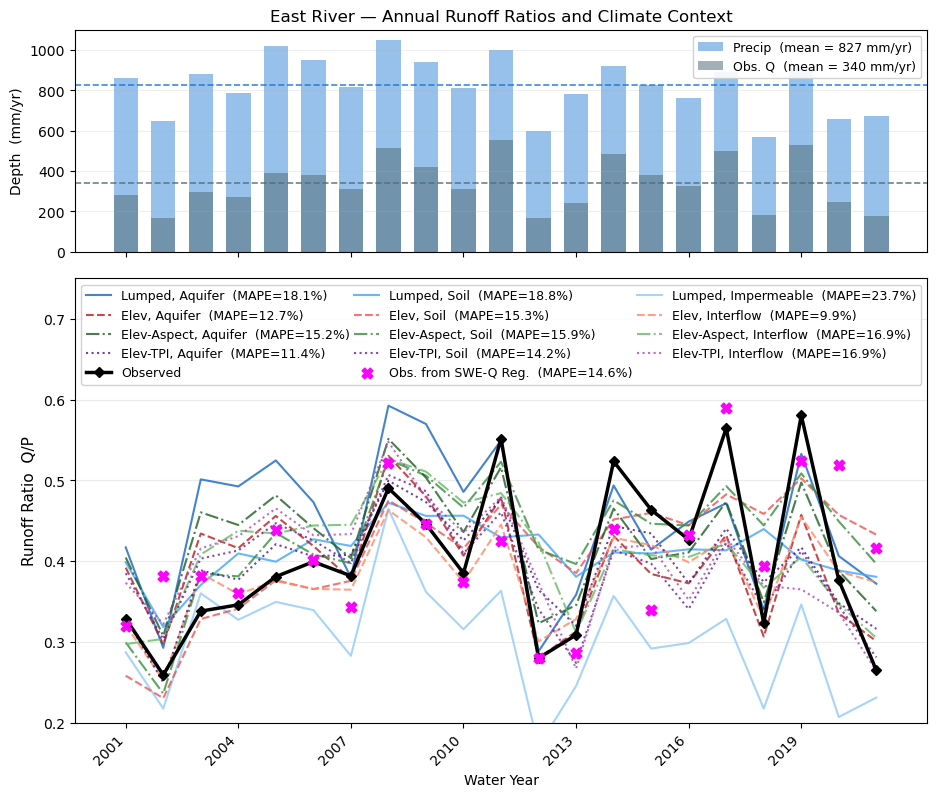

In [30]:
# Runoff ratio (Q/P) by water year
# Two panels: P+Q climate context (top) | Q/P spaghetti with MAPE (bottom)

import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Precipitation: use pptrate from lumped bigBuckt output (same ERA5 for all) ---
ds_p = xr.open_dataset(model_files['lumped']['bigBuckt'])
area_lump = domain_areas['lumped']
p_rate = ds_p['pptrate'].squeeze()                        # kg m-2 s-1
p_daily = (p_rate * 86400).resample(time='1D').mean()    # mm/day
x = np.arange(2001, 2022)

precip_wy = {}
for wy in range(2001, 2022):
    p_wy = p_daily.sel(time=slice(f"{wy-1}-10-01", f"{wy}-09-30"))
    if len(p_wy) > 0:
        precip_wy[wy] = float(p_wy.sum())
precip_series = pd.Series(precip_wy)

# --- Observed Q in depth (mm/yr) ---
obs_q_mm = {}
for wy in range(2001, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_q_mm[wy] = obs_wy.sum() * 86400 / area_lump * 1000  # m3/s -> mm/yr
obs_q_mm = pd.Series(obs_q_mm)

# --- Modeled Q in depth (mm/yr) per model ---
rr_box_data, rr_years = [], []
for wy in sorted(precip_series.index):
    if wy not in obs_q_mm.index:
        continue
    p_mm = precip_series[wy]
    model_rr = []
    for (domain, model_key), sim_df in annual_q_dict.items():
        if wy not in sim_df.index:
            continue
        area = domain_areas[domain]
        q_mm = sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000
        model_rr.append(q_mm / p_mm)
    if model_rr:
        rr_box_data.append(model_rr)
        rr_years.append(wy)

obs_rr = obs_q_mm / precip_series
obs_rr = obs_rr.dropna()

# SWE-Q regression runoff ratio
obs_q_from_swe = obs_apr1 * 0.97 + 6.98
obs_rr_from_swe = obs_q_from_swe / precip_series
obs_rr_from_swe = obs_rr_from_swe.dropna()

# --- Observed RR aligned to rr_years for MAPE calculation ---
obs_rr_aligned = obs_rr.reindex(rr_years)

# --- Figure: 2 panels (P+Q top, Q/P bottom) ---
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={'hspace': 0.08, 'height_ratios': [1, 2]})

# --- Panel 1 (top): Precipitation + Observed Q, overlaid, translucent ---
ax_clim = axes[0]
mean_p = precip_series.reindex(rr_years).mean()
mean_q = obs_q_mm.reindex(rr_years).mean()

ax_clim.bar(x, precip_series.reindex(rr_years).values,
            color='#1976D2', alpha=0.45, width=0.65,
            label=f'Precip  (mean = {mean_p:.0f} mm/yr)')
ax_clim.bar(x, obs_q_mm.reindex(rr_years).values,
            color='#546E7A', alpha=0.55, width=0.65,
            label=f'Obs. Q  (mean = {mean_q:.0f} mm/yr)')
ax_clim.axhline(mean_p, color='#1976D2', linestyle='--', linewidth=1.2, alpha=0.85)
ax_clim.axhline(mean_q, color='#546E7A', linestyle='--', linewidth=1.2, alpha=0.85)
ax_clim.set_ylabel('Depth  (mm/yr)', fontsize=10)
ax_clim.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax_clim.grid(True, alpha=0.2, axis='y')
ax_clim.set_title('East River — Annual Runoff Ratios and Climate Context', fontsize=12)

# --- Panel 2 (bottom): Q/P spaghetti with MAPE labels ---
ax = axes[1]

for (domain, model_key), sim_df in annual_q_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    area = domain_areas[domain]
    rr_vals = {
        wy: (sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000) / precip_series[wy]
        for wy in sim_df.index
        if wy in precip_series.index and precip_series[wy] > 0
    }
    rr_s = pd.Series(rr_vals).reindex(rr_years)
    common = obs_rr_aligned.notna() & rr_s.notna()
    mape = np.mean(np.abs(rr_s[common].values - obs_rr_aligned[common].values)
                   / np.abs(obs_rr_aligned[common].values)) * 100
    ax.plot(x, rr_s.values,
            color=style['color'], linestyle=style['ls'],
            linewidth=1.5, alpha=0.8,
            label=f"{style['label']}  (MAPE={mape:.1f}%)")

# Observed Q/P
ax.plot(x, obs_rr.reindex(rr_years).values,
        color='black', linewidth=2.5, marker='D', markersize=5,
        zorder=10, label='Observed')

# SWE-Q regression with MAPE vs observed
obs_rr_swe_aligned = obs_rr_from_swe.reindex(rr_years)
common_swe = obs_rr_aligned.notna() & obs_rr_swe_aligned.notna()
mape_swe = np.mean(np.abs(obs_rr_swe_aligned[common_swe].values - obs_rr_aligned[common_swe].values)
                   / np.abs(obs_rr_aligned[common_swe].values)) * 100
ax.scatter(x, obs_rr_swe_aligned.values,
           color='magenta', marker='X', s=60, zorder=11,
           label=f'Obs. from SWE-Q Reg.  (MAPE={mape_swe:.1f}%)')

ax.set_ylabel('Runoff Ratio  Q/P', fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25, axis='y')
order = [0,3,7,9,12,1,4,6,10, 13,2,5,8, 11]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[handles[i] for i in order], labels=[labels[i] for i in order], fontsize=9, ncol=3, loc='upper left', framealpha=0.9, 
          # increase the height of the legend bbox
          bbox_to_anchor=(0, 0.8, 1, 0.2), mode='expand',
          # align text right
          alignment='right'
          )

ax.set_xticks(x[::3])
ax.set_xticklabels(rr_years[::3], rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Water Year', fontsize=10)
ax.set_ylim(0.2,0.75)

# plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_runoff_ratio_wy.png',
#             dpi=150, bbox_inches='tight')
plt.show()

## October 1 soil moisture by model type

Text(0.5, 1.0, 'East River — October 1 Soil Moisture by Model\n(scalarTotalSoilLiq, normalized)')

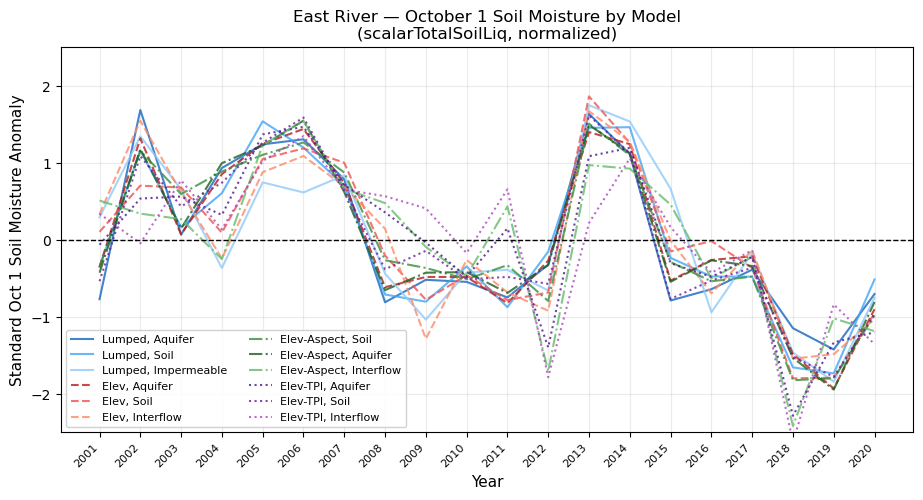

In [31]:
# plot October 1 soil moisture across models as spaghetti plot using scalarTotalSoiLiq
october_1_dates = pd.date_range(start='2001-09-30', end='2021-09-30', freq='YS-OCT')
fig, ax = plt.subplots(figsize=(11, 5))

for (domain, model_key), sim_df in swe_daily_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarTotalSoilLiq' not in ds.data_vars:
        continue
    soil_liq = ds['scalarTotalSoilLiq'].mean(dim='hru').resample(time='1D').mean().squeeze()  # mm
    soi_liq_oct1 = []
    for date in october_1_dates:
        if date in soil_liq.time.values:
            soi_liq_oct1.append(float(soil_liq.sel(time=date).values))
        else:
            soi_liq_oct1.append(float(soil_liq.interp(time=date).values))
    soi_liq_s = pd.Series(soi_liq_oct1, index=october_1_dates.year)
    # normalize by the mean of each model
    soi_liq_s = (soi_liq_s - soi_liq_s.mean()) / soi_liq_s.std()
    ax.plot(soi_liq_s.index, soi_liq_s.values,
            color=style['color'], linestyle=style['ls'],
            linewidth=1.5, alpha=0.8, label=style['label'])
plt.axhline(0, color='k', ls='--', lw=1.0, alpha=1.0)
plt.xticks(october_1_dates.year, rotation=45, ha='right', fontsize=8)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Standard Oct 1 Soil Moisture Anomaly', fontsize=11)
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, ncol=2, loc='lower left', framealpha=0.9)
plt.ylim(-2.5, 2.5)
plt.title('East River — October 1 Soil Moisture by Model\n'
          '(scalarTotalSoilLiq, normalized)', fontsize=12)



## ET time series by model type

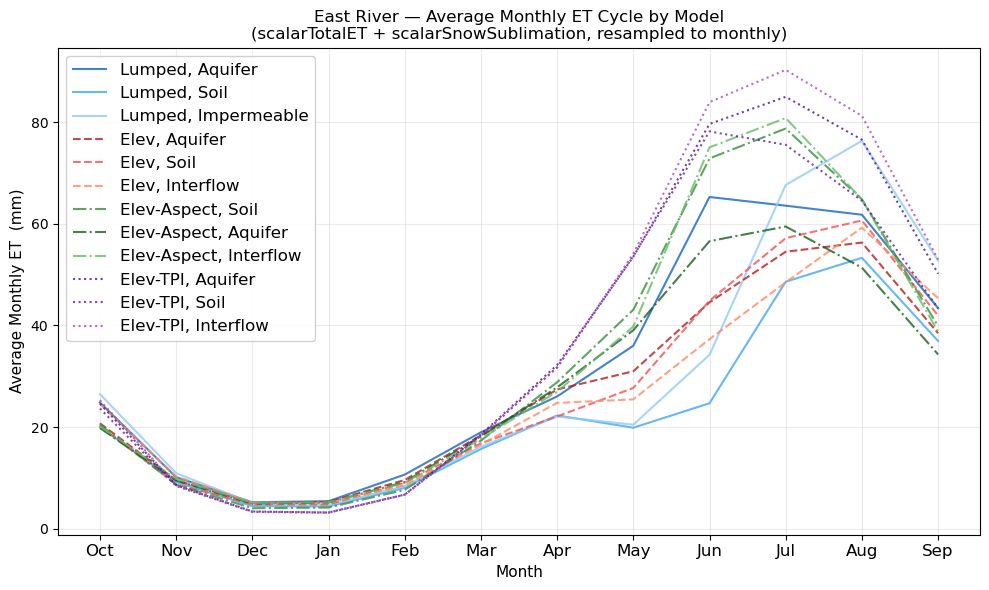

In [32]:
# plot average monthly ET cycle across all models. 
fig, ax = plt.subplots(figsize=(10, 6))
for (domain, model_key), sim_df in annual_q_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarTotalET' not in ds.data_vars:
        continue
    et_monthly = (-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).mean(dim='hru').to_pandas()
    et_monthly = et_monthly.resample('1ME').sum()
    monthly_mean = et_monthly.groupby(et_monthly.index.month).mean()
    # order from October (10) to September (9)
    monthly_mean = monthly_mean.reindex([10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]).reset_index()

    ax.plot(monthly_mean.index, monthly_mean[0],
            color=style['color'], linestyle=style['ls'],
            linewidth=1.5, alpha=0.8, label=style['label'])
ax.set_xticks(range(0, 12))
ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'], fontsize=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average Monthly ET  (mm)', fontsize=11)
ax.set_title('East River — Average Monthly ET Cycle by Model\n'
             '(scalarTotalET + scalarSnowSublimation, resampled to monthly)', fontsize=12)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=12, ncol=1, loc='upper left', framealpha=0.9)
plt.tight_layout()



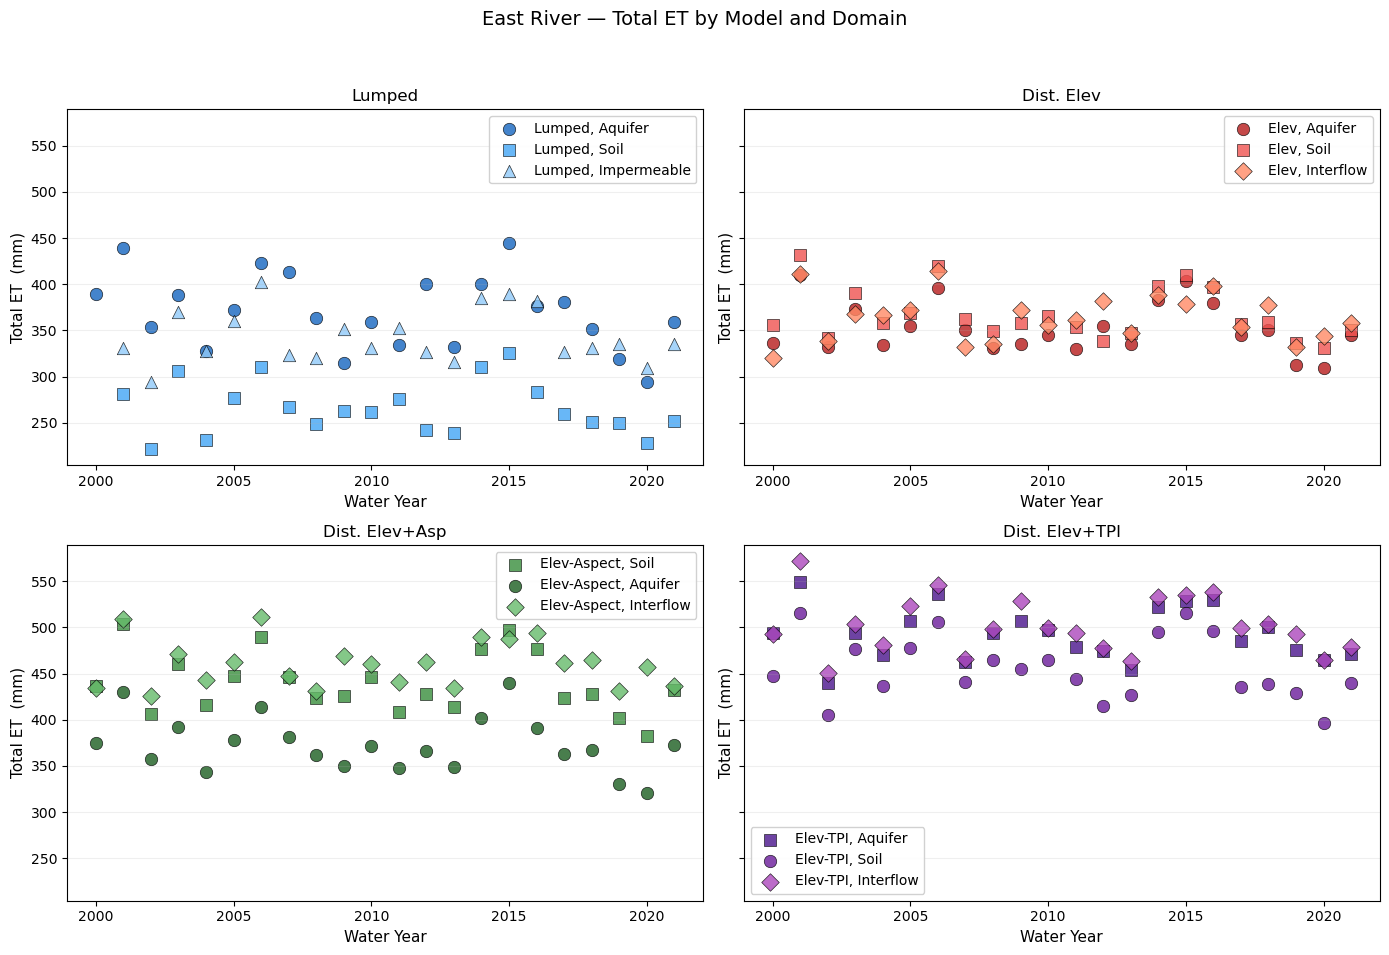

In [33]:
# plot a 2x2 panel plot with bar plots of the Total ET timeseries for each year for each domain 
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
# shape for each model type
shapes = {
    'bigBuckt':          'o',
    'noXplict_drainage': 's',
    'noXplict_zeroFlux': '^',
    'qTopmodl':          'D',
}
for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    ax = axes[i//2, i%2]
    for model_key in model_discharge[domain].keys():
        style = model_styles.get(domain, {}).get(model_key)
        
        if style is None:
            continue
        filepath = model_files[domain][model_key]
        hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        # calculate weighted mean ET

        et_daily = ((-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
        et_daily = et_daily.resample('1D').sum()
        et_annual = et_daily.resample('YS-SEP').sum()
        # drop years after 2021
        et_annual = et_annual[et_annual.index.year <= 2020]
        # add 1 year to get water year
        et_annual.index = et_annual.index + pd.offsets.DateOffset(years=1)
        ax.scatter(et_annual.index.year, et_annual.values,
                   color=style['color'], marker=shapes.get(model_key, 'o'), s=80, edgecolors='k', linewidths=0.5, alpha=0.8, label=style['label'])
    ax.set_title(f"{domain_labels[domain]}", fontsize=12)
    ax.set_xlabel('Water Year', fontsize=11)
    ax.set_ylabel('Total ET  (mm)', fontsize=11)
    ax.grid(True, alpha=0.2, axis='y')
    ax.legend(fontsize=10, framealpha=0.9)
# plt.ylim(100,500)
plt.suptitle('East River — Total ET by Model and Domain', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Sublimation time-series by model type

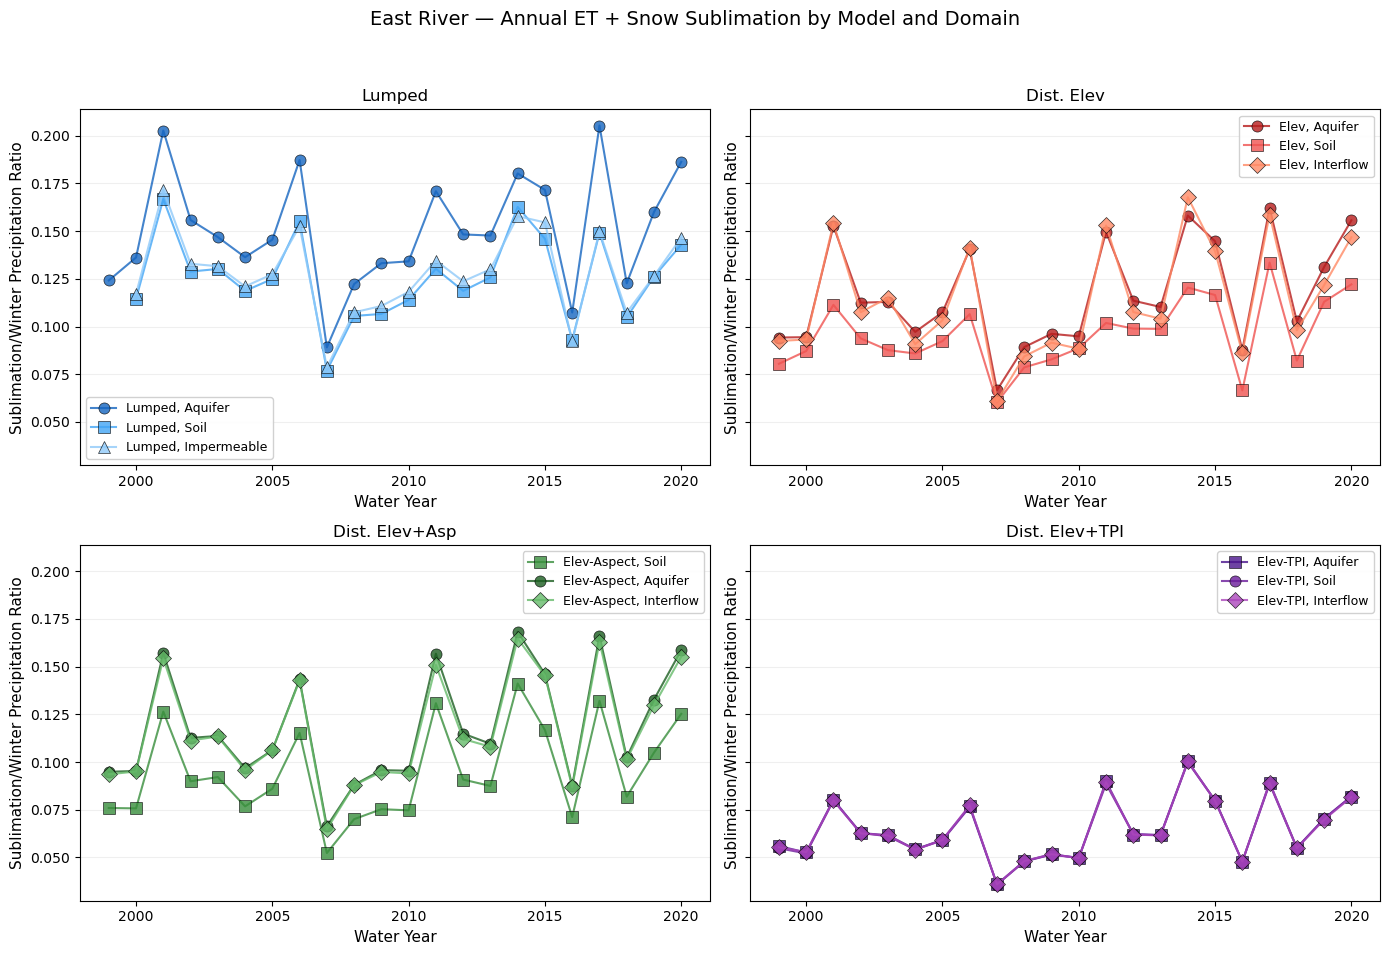

In [34]:
# plot a 2x2 panel plot with bar plots of the annual ET + snow sublimation timeseries for each year for each domain 
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
# shape for each model type
shapes = {
    'bigBuckt':          'o',
    'noXplict_drainage': 's',
    'noXplict_zeroFlux': '^',
    'qTopmodl':          'D',
}
for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    ax = axes[i//2, i%2]
    for model_key in model_discharge[domain].keys():
        style = model_styles.get(domain, {}).get(model_key)
        if style is None:
            continue
        filepath = model_files[domain][model_key]
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        sub_daily = ((-(ds['scalarSnowSublimation'].where(ds.time.dt.month.isin([12,1,2,3,4])))*3600)).mean(dim='hru').to_pandas()
        winter_ppt = (ds['pptrate'].where(ds.time.dt.month.isin([12,1,2,3,4]))*3600).mean(dim='hru').resample(time='YS-OCT').sum().to_pandas()

        sub_daily = sub_daily.resample('1D').sum()
        sub_annial = sub_daily.resample('YS-OCT').sum()/winter_ppt
        # drop years after 2021
        sub_annial = sub_annial[sub_annial.index.year <= 2021]
        ax.plot(sub_annial.index.year, sub_annial.values,
                   color=style['color'], marker=shapes.get(model_key, 'o'), ms=8, markeredgecolor='k', markeredgewidth=0.5, alpha=0.8, label=style['label'])
    ax.set_title(f"{domain_labels[domain]}", fontsize=12)
    ax.set_xlabel('Water Year', fontsize=11)
    ax.set_ylabel('Sublimation/Winter Precipitation Ratio', fontsize=11)
    ax.grid(True, alpha=0.2, axis='y')
    ax.legend(fontsize=9, framealpha=0.9)
plt.suptitle('East River — Annual ET + Snow Sublimation by Model and Domain', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Aquifer storage accross domain types

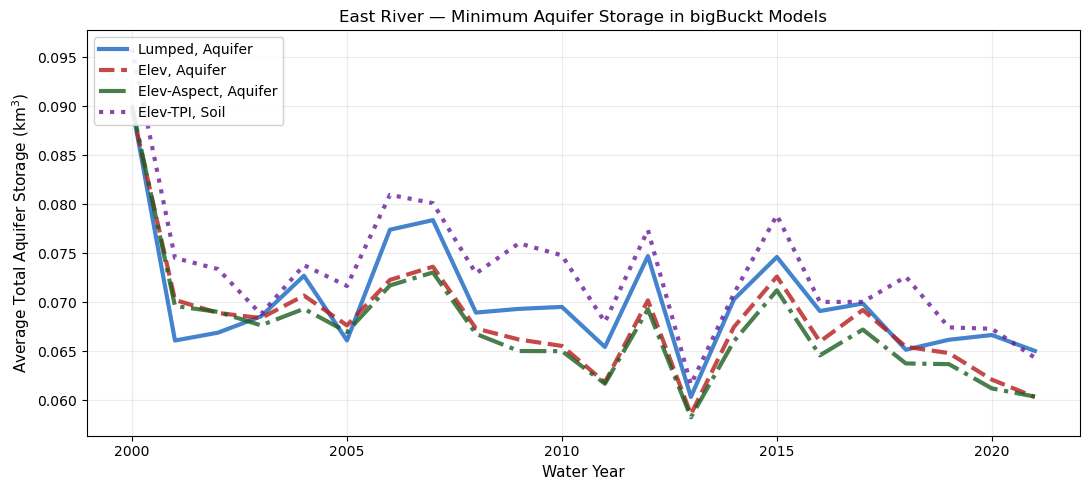

In [35]:
# compare scalarAquiferStorage_mean across bigBuckt models 
import geopandas as gpd
basin_area_m2 = gpd.read_file("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp")['HRU_area']
fig, ax = plt.subplots(figsize=(11, 5))
for (domain, model_key), sim_df in annual_q_dict.items():
    if model_key != 'bigBuckt':
        continue
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarAquiferStorage_mean' not in ds.data_vars:
        continue
    aquifer_storage = ds['scalarAquiferStorage_mean'].mean(dim='hru').to_pandas()
    aquifer_storage = aquifer_storage.resample('1D').mean()
    aquifer_annual = aquifer_storage.resample('YE-SEP').min()
    # drop years after 2021
    aquifer_annual = aquifer_annual[(aquifer_annual.index.year <= 2021) & (aquifer_annual.index.year >= 2000)]
    # add 1 year to get water year
    aquifer_annual.index = aquifer_annual.index
    ax.plot(aquifer_annual.index.year, aquifer_annual.values*basin_area_m2.mean()/1e9,
            color=style['color'], linestyle=style['ls'], ms=8, markeredgecolor='k', markeredgewidth=0.5,
            linewidth=3.0, alpha=0.8, label=style['label'])
ax.set_xlabel('Water Year', fontsize=11)
ax.set_ylabel('Average Total Aquifer Storage (km$^3$)', fontsize=11)
ax.set_title('East River — Minimum Aquifer Storage in bigBuckt Models', fontsize=12)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

In [69]:
# Annual total water storage and storage change by model/domain
storage_total = {}
storage_change = {}

def _area_weighted_series(da, hru_areas):
    if 'hru' in da.dims:
        df = da.to_pandas()
        return (df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
    return da.to_pandas()

for domain, files in model_files.items():
    with xr.open_dataset(attr_paths[domain]) as attrs:
        hru_areas = attrs['HRUarea'].load()
    for model_key, filepath in files.items():
        with xr.open_dataset(filepath) as ds:
            soil_liq_var = None
            if 'scalarTotalSoilLiq' in ds.data_vars:
                soil_liq_var = 'scalarTotalSoilLiq'
            elif 'scalarTotalSoilLiq_mean' in ds.data_vars:
                soil_liq_var = 'scalarTotalSoilLiq_mean'
            if soil_liq_var is None:
                continue
            soil_ice_var = None
            if 'scalarTotalSoilIce' in ds.data_vars:
                soil_ice_var = 'scalarTotalSoilIce'
            elif 'scalarTotalSoilIce_mean' in ds.data_vars:
                soil_ice_var = 'scalarTotalSoilIce_mean'
            if soil_ice_var is None:
                continue
            aquifer_var = None
            if 'scalarAquiferStorage_mean' in ds.data_vars:
                aquifer_var = 'scalarAquiferStorage_mean'
            elif 'scalarAquiferStorage' in ds.data_vars:
                aquifer_var = 'scalarAquiferStorage'

            soil_liq = _area_weighted_series(ds[soil_liq_var], hru_areas)
            soil_ice = _area_weighted_series(ds[soil_ice_var], hru_areas)
            if aquifer_var is None:
                aquifer = soil_liq * 0.0
            else:
                aquifer = _area_weighted_series(ds[aquifer_var], hru_areas)
            snow_storage = _area_weighted_series(ds['scalarSWE'], hru_areas) if 'scalarSWE' in ds.data_vars else soil_liq * 0.0

            total_storage = (aquifer * 1000.0) 
            total_storage = total_storage.sort_index()
            total_storage_change = total_storage.where(total_storage.index.year > 2000).resample('YS-OCT').mean().diff()

            key = (domain, model_key)
            storage_change[key] = total_storage_change

storage_change_df = pd.DataFrame(storage_change)
storage_change_df.columns = pd.MultiIndex.from_tuples(storage_change_df.columns, names=['domain', 'model'])


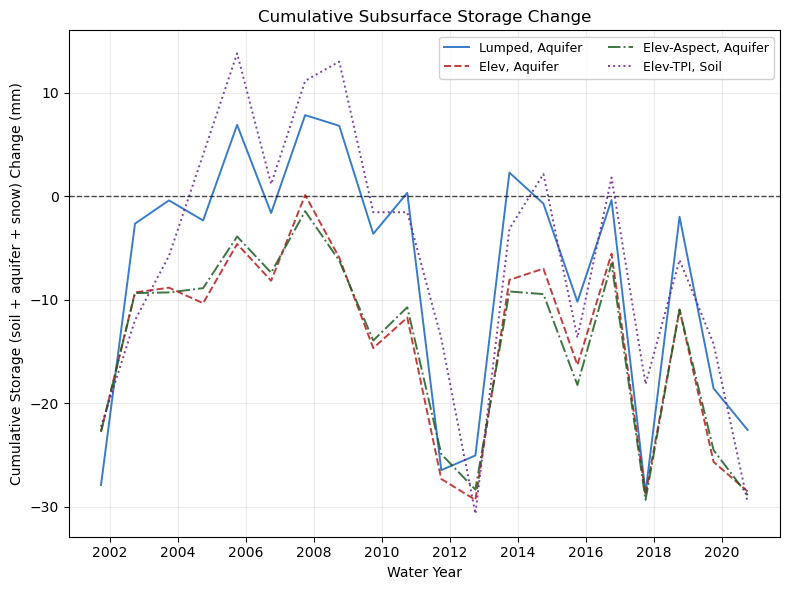

In [70]:

fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
for domain, model_key in storage_change_df.columns:
    if model_key != 'bigBuckt':
        continue
    style = model_styles.get(domain, {}).get(model_key, {})
    label = style.get('label', f"{domain}-{model_key}")
    color = style.get('color', None)
    ls = style.get('ls', '-')
    change_series = storage_change_df[(domain, model_key)].dropna()
    if (domain == 'distributed_elevTPI') & (model_key=="qTopmodl"):
        change_series = change_series/2
    cumulative_change = change_series.cumsum()
    ax.plot(cumulative_change.index, cumulative_change.values, color=color, linestyle=ls, linewidth=1.4, alpha=0.85, label=label)

ax.axhline(0, color='k', lw=1, ls='--', alpha=0.7)
ax.set_xlabel('Water Year')
ax.set_ylabel('Cumulative Storage (soil + aquifer + snow) Change (mm)')
ax.set_title('Cumulative Subsurface Storage Change')
ax.grid(True, alpha=0.25)
ax.legend(ncols=2, fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

In [239]:
# for the bigBuckt models, lets make a stacked bar plot of storage by year to show how storage is distributed
domain =  'distributed_elevTPI'
model = 'bigBuckt'
# get the data for soil liquid, soil ice, aquifer, and snow storage for each water year
with xr.open_dataset(attr_paths[domain]) as attrs:
    hru_areas = attrs['HRUarea'].load()

with xr.open_dataset(model_files[domain][model]) as ds:
    soil_liq_var = None
    if 'scalarTotalSoilLiq' in ds.data_vars:
        soil_liq_var = 'scalarTotalSoilLiq'
    elif 'scalarTotalSoilLiq_mean' in ds.data_vars:
        soil_liq_var = 'scalarTotalSoilLiq_mean'

    soil_ice_var = None
    if 'scalarTotalSoilIce' in ds.data_vars:
        soil_ice_var = 'scalarTotalSoilIce'
    elif 'scalarTotalSoilIce_mean' in ds.data_vars:
        soil_ice_var = 'scalarTotalSoilIce_mean'

    aquifer_var = None
    if 'scalarAquiferStorage_mean' in ds.data_vars:
        aquifer_var = 'scalarAquiferStorage_mean'
    elif 'scalarAquiferStorage' in ds.data_vars:
        aquifer_var = 'scalarAquiferStorage'

    soil_liq = _area_weighted_series(ds[soil_liq_var], hru_areas)
    soil_ice = _area_weighted_series(ds[soil_ice_var], hru_areas)
    if aquifer_var is None:
        aquifer = soil_liq * 0.0
    else:
        aquifer = _area_weighted_series(ds[aquifer_var], hru_areas)

    snow_storage = _area_weighted_series(ds['scalarSWE'], hru_areas) if 'scalarSWE' in ds.data_vars else soil_liq * 0.0

# group each by water year mean 
soil_wy = (soil_liq+soil_ice).where(soil_liq.index.year > 2000).resample('YS-OCT').last()
aquifer_wy = aquifer.where(aquifer.index.year > 2000).resample('YS-OCT').last()
snow_wy = snow_storage.where((snow_storage.index.year < 2021) & (snow_storage.index.year > 1999)).resample('YE-JUL').last().dropna()
snow_wy.index = soil_wy.index[:len(snow_wy)]
snow_wy.iloc[-1] = snow_wy.iloc[-1] * 0

In [237]:
# groundwater observations 
gw_obs = pd.read_csv("/scratch/dlhogan/ess-project-data/groundwater-data/east_ph_gw_2018to2022/data/er_plm6_waterlevel_daily_2016-2022.csv", parse_dates=['Date_time'], skiprows=5, index_col='Date_time')
gw_obs2 = pd.read_csv("/scratch/dlhogan/ess-project-data/groundwater-data/east_ph_gw_2018to2022/data/er_plm1_waterlevel_daily_2016-2022.csv", parse_dates=['Date_time'], skiprows=5, index_col='Date_time')
# mean observed storage by wy
gw_obs_wy = gw_obs['Waterlevel_1d_trend'].where(gw_obs.index.year > 2017).resample('YE-SEP').last()
gw_obs_wy.index = gw_obs_wy.index.year 

gw_obs2_wy = gw_obs2['Waterlevel_1d_trend'].where(gw_obs2.index.year > 2017).resample('YE-SEP').last()
gw_obs2_wy.index = gw_obs2_wy.index.year

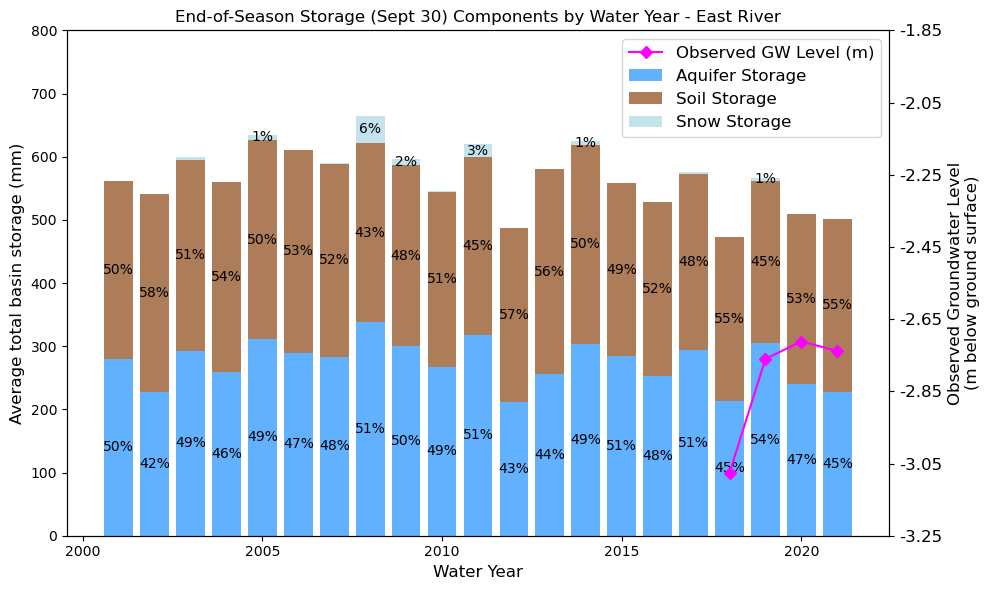

In [242]:
# stacked bar chart by year
fig, ax = plt.subplots(figsize=(10, 6))

aquifer_mm = aquifer_wy.values * 1000 * 2
soil_mm = soil_wy.values
snow_mm = snow_wy.values
total_mm = aquifer_mm + soil_mm + snow_mm

ax.bar(aquifer_wy.index.year+1, aquifer_mm, label='Aquifer Storage', color='#1E90FF', alpha=0.7)
ax.bar(soil_wy.index.year+1, soil_mm, label='Soil Storage', bottom=aquifer_mm, color='#8B4513', alpha=0.7)
ax.bar(snow_wy.index.year+1, snow_mm, bottom=aquifer_mm + soil_mm, label='Snow Storage', color='#ADD8E6', alpha=0.7)

# add percent labels for each category per year
for i, year in enumerate(aquifer_wy.index.year):
    if total_mm[i] == 0:
        continue
    aquifer_pct = aquifer_mm[i] / total_mm[i] * 100.0
    soil_pct = soil_mm[i] / total_mm[i] * 100.0
    snow_pct = snow_mm[i] / total_mm[i] * 100.0

    aquifer_mid = aquifer_mm[i] / 2.0
    soil_mid = aquifer_mm[i] + soil_mm[i] / 2.0
    snow_mid = aquifer_mm[i] + soil_mm[i] + snow_mm[i] / 2.0

    if aquifer_mm[i] > 5:
        ax.text(year+1, aquifer_mid, f"{aquifer_pct:.0f}%", ha='center', va='center', fontsize=10, color='black')
    if soil_mm[i] > 5:
        ax.text(year+1, soil_mid, f"{soil_pct:.0f}%", ha='center', va='center', fontsize=10, color='black')
    if snow_mm[i] > 5:
        ax.text(year+1, snow_mid, f"{snow_pct:.0f}%", ha='center', va='center', fontsize=10, color='black')

ax2= ax.twinx()

ax2.plot(gw_obs_wy[1:-2].index, gw_obs_wy[1:-2], color='magenta', marker='D', markersize=6, label='Observed GW Level', zorder=10)
ax2.set_ylim(2.7565e3, 2.7578e3)
# dummy plot for legend
ax.plot([], [], color='magenta', marker='D', markersize=6, label='Observed GW Level (m)', zorder=10)
# change y-axis ticks to be in meters below ground surface, assuming 2757.5 m is the ground surface elevation
gw_ticks = ax2.get_yticks()
gw_tick_labels = [f"-{2759.65 - tick:.2f}" for tick in gw_ticks]
ax2.set_yticks(gw_ticks)
ax2.set_yticklabels(gw_tick_labels, fontsize=12)
ax2.set_ylabel('Observed Groundwater Level\n(m below ground surface)', fontsize=12)
ax.set_xlabel('Water Year', fontsize=12)
ax.set_ylabel('Average total basin storage (mm)', fontsize=12)
ax.set_title(f'End-of-Season Storage (Sept 30) Components by Water Year - East River', fontsize=12)
ax.set_ylim(0, 800)
ax.legend(fontsize=12)
plt.tight_layout()

## Spatial mean and variability

In [35]:
import geopandas as gpd
shapefile_catchment_dirs = {
    'lumped':              '/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment',
    'distributed_elev':    '/scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment',
    'distributed_elevAspect': '/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment',
    'distributed_elevTPI': '/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevTPI/shapefiles/catchment',
}

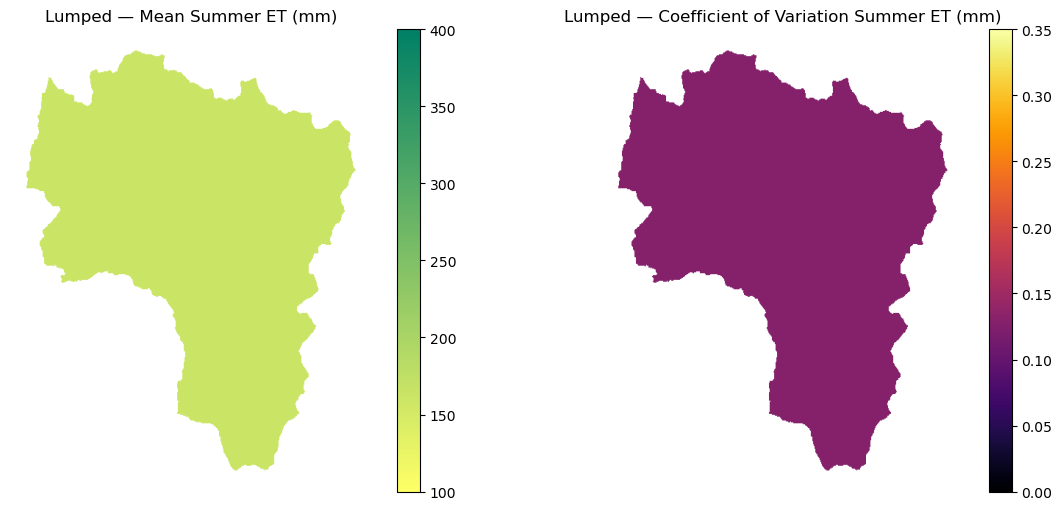

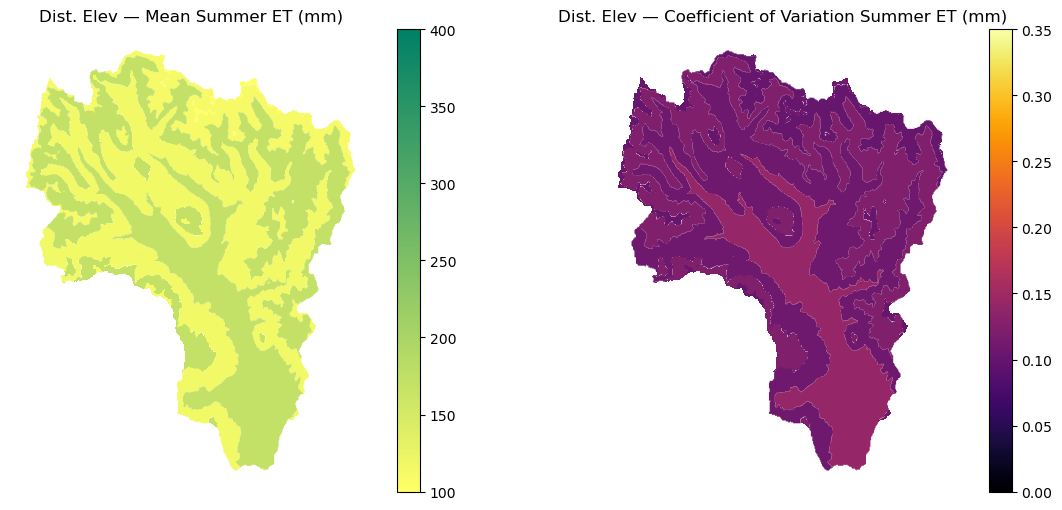

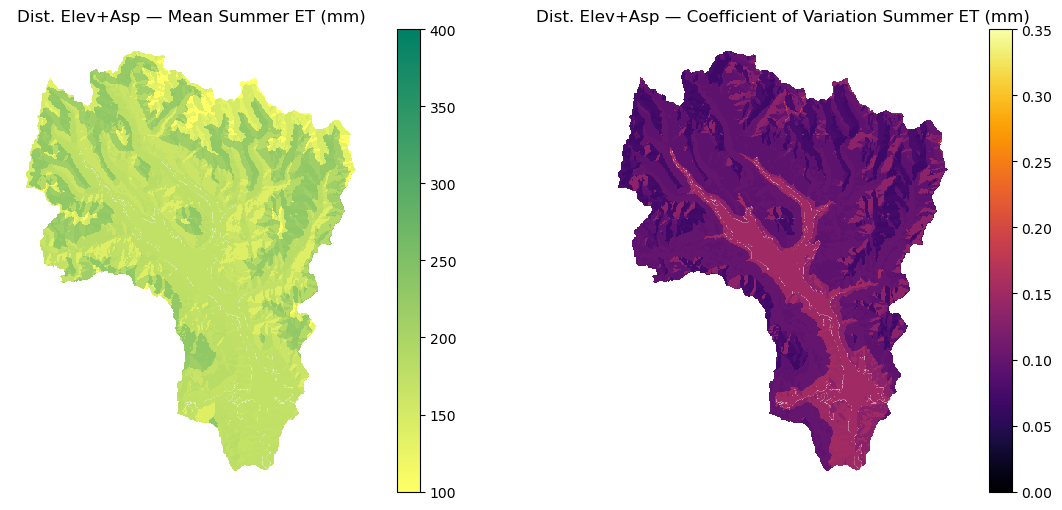

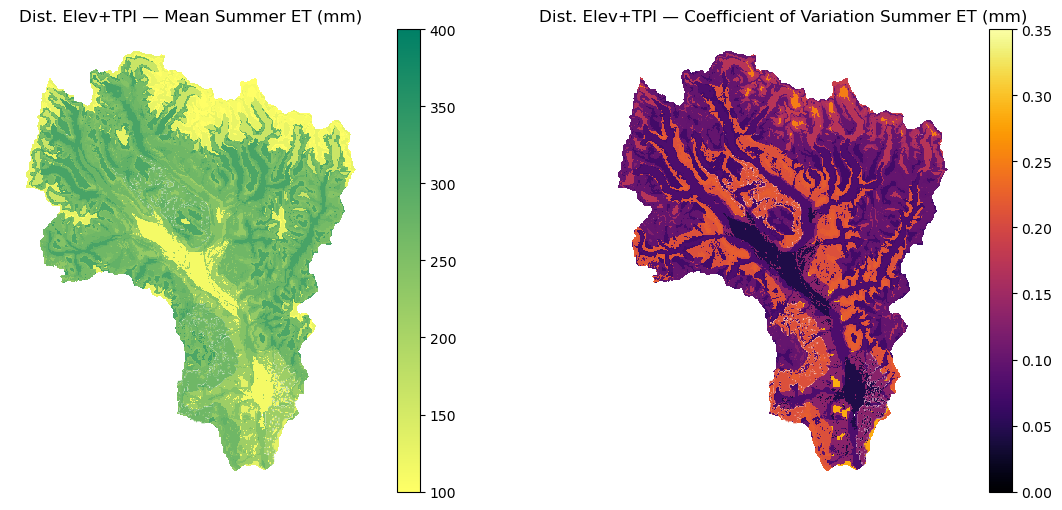

In [36]:
from glob import glob
# 2x2 plot of spatial maps of variable of choice 
var_to_plot = 'scalarTotalET'  # example variable

for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    shapefile_dir = shapefile_catchment_dirs[domain]
    # grab the first shapefile
    shapefile_path = glob(f"{shapefile_dir}/*.shp")[0]
    gdf = gpd.read_file(shapefile_path)
    months_to_plot = [5,6,7]
    ds = xr.open_dataset(model_files[domain]['bigBuckt'])
    # plot the mean scalarTotalET filled into the basin
    summer_et = (-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).where(ds.time.dt.month.isin(months_to_plot)).resample(time='YS-APR').sum().sel(time=slice('2002', '2021'))
    summer_et_mean = summer_et.mean(dim='time')
    summer_et_cv = summer_et.std(dim='time') / summer_et.mean(dim='time')
    gdf['mean_et'] = gdf['HRU_ID'].apply(lambda hru_id: float(summer_et_mean.sel(hru=hru_id).values))
    gdf['cv_et'] = gdf['HRU_ID'].apply(lambda hru_id: float(summer_et_cv.sel(hru=hru_id).values))

    ax = axs[0]
    gdf.plot(column='mean_et', cmap='summer_r', legend=True, ax=ax,vmin=100, vmax=400)
    ax.set_title(f"{domain_labels[domain]} — Mean Summer ET (mm)", fontsize=12)
    ax.set_axis_off()

    ax = axs[1]
    gdf.plot(column='cv_et', cmap='inferno', legend=True, ax=ax, vmin=0, vmax=0.35)
    ax.set_title(f"{domain_labels[domain]} — Coefficient of Variation Summer ET (mm)", fontsize=12)
    ax.set_axis_off()

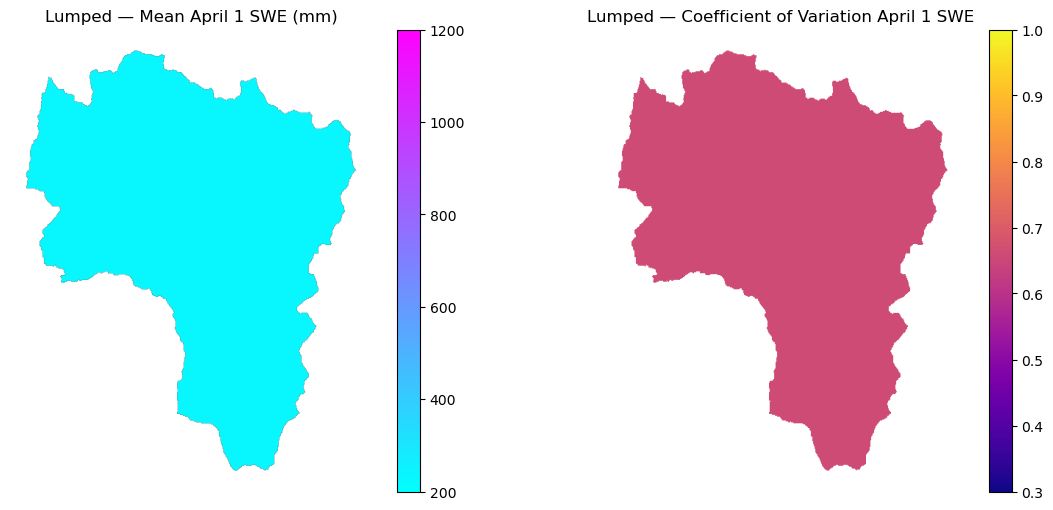

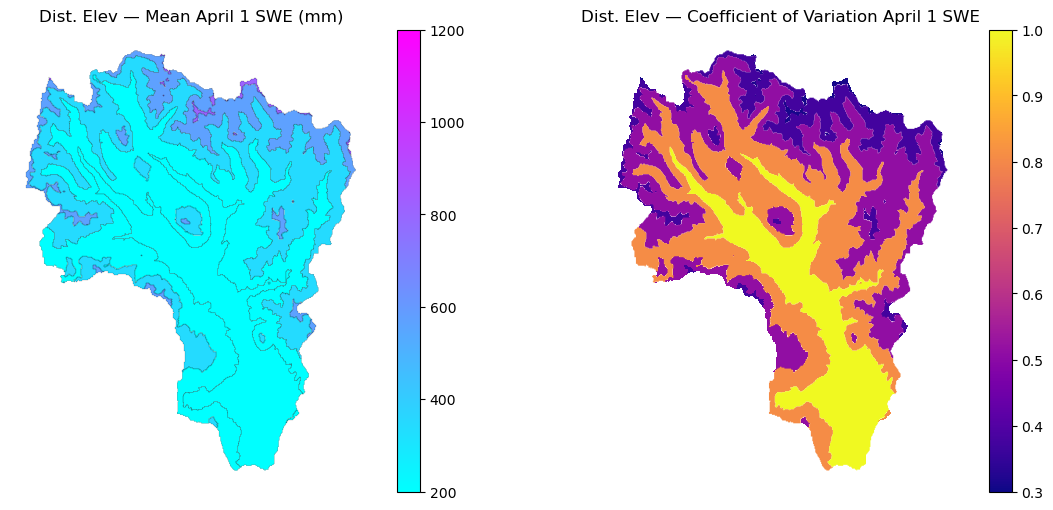

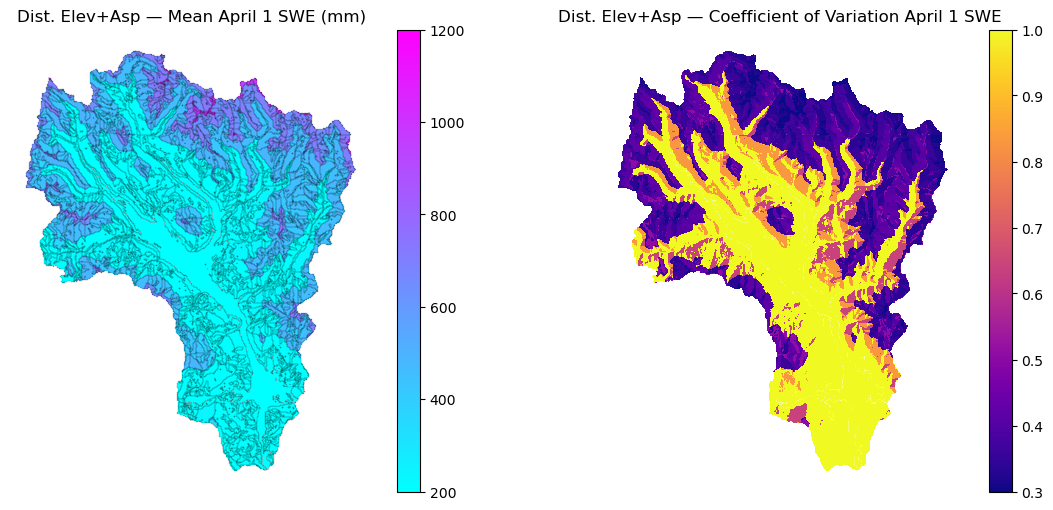

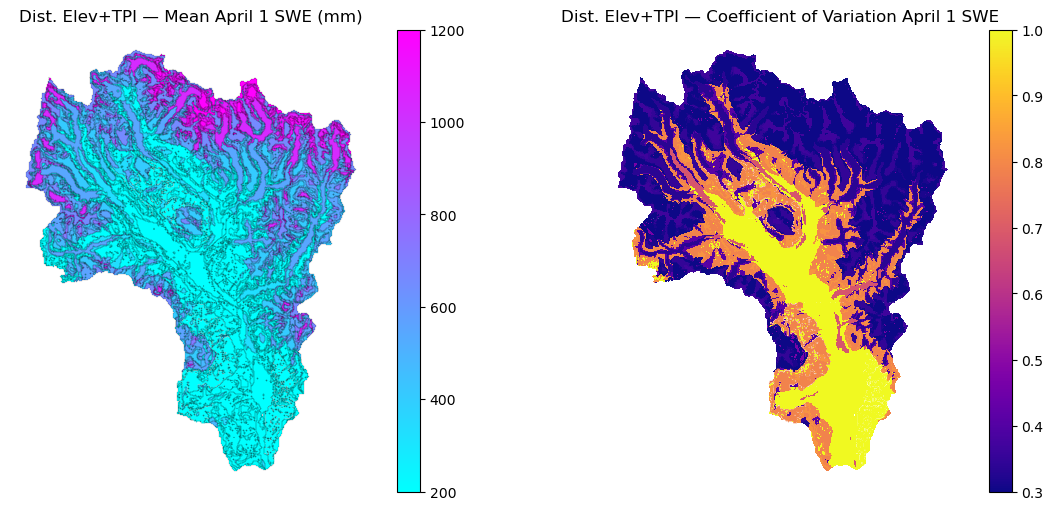

In [37]:
from glob import glob
# 2x2 plot of spatial maps of variable of choice 
var_to_plot = 'scalarTotalET'  # example variable

for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    shapefile_dir = shapefile_catchment_dirs[domain]
    # grab the first shapefile
    shapefile_path = glob(f"{shapefile_dir}/*.shp")[0]
    gdf = gpd.read_file(shapefile_path)
    month_to_plot = 5
    day_to_plot = 1
    ds = xr.open_dataset(model_files[domain]['bigBuckt'])
    # plot the mean scalarTotalET filled into the basin
    apr1_swe = (ds['scalarSWE']).where((ds.time.dt.month == month_to_plot) & (ds.time.dt.day == day_to_plot)).resample(time='YE-APR').max().sel(time=slice('2002', '2021'))
    apr1_swe_mean = apr1_swe.mean(dim='time')
    apr1_swe_cv = apr1_swe.std(dim='time') / apr1_swe_mean
    gdf['mean_apr1_swe'] = gdf['HRU_ID'].apply(lambda hru_id: float(apr1_swe_mean.sel(hru=hru_id).values))
    gdf['cv_apr1_swe'] = gdf['HRU_ID'].apply(lambda hru_id: float(apr1_swe_cv.sel(hru=hru_id).values))

    ax = axs[0]
    gdf.plot(column='mean_apr1_swe', cmap='cool', legend=True, ax=ax, vmin=200, vmax=1200)
    # plot hru outlines
    gdf.boundary.plot(color='k', linewidth=0.2, ax=ax, alpha=0.5)
    ax.set_title(f"{domain_labels[domain]} — Mean April 1 SWE (mm)", fontsize=12)
    ax.set_axis_off()

    ax = axs[1]
    gdf.plot(column='cv_apr1_swe', cmap='plasma', legend=True, ax=ax, vmin=0.3, vmax=1.0)
    ax.set_title(f"{domain_labels[domain]} — Coefficient of Variation April 1 SWE ", fontsize=12)
    ax.set_axis_off()

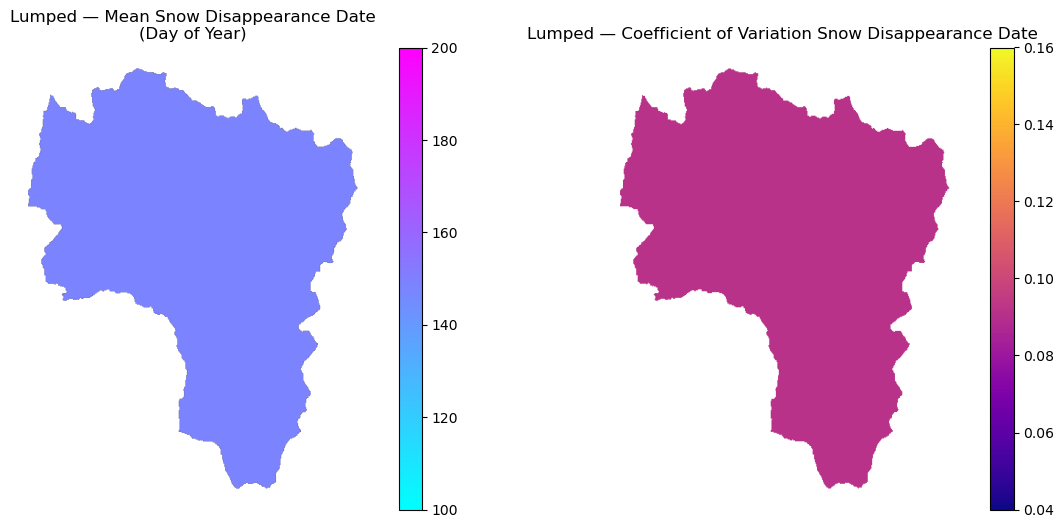

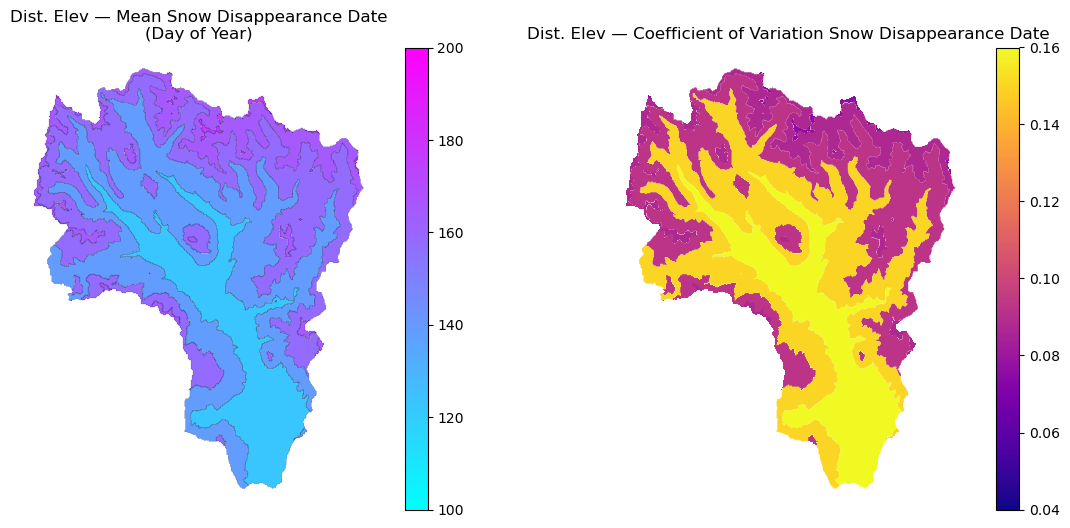

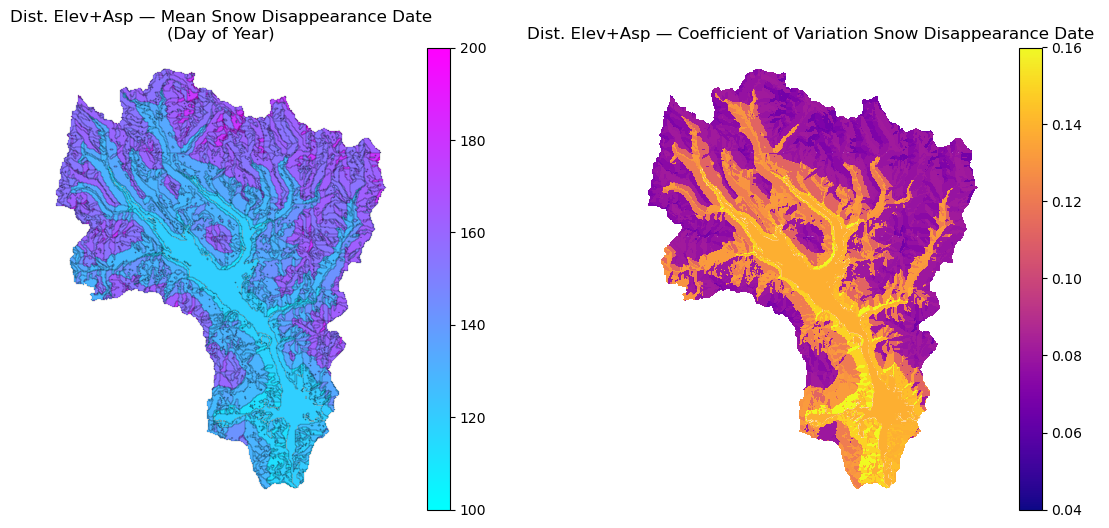

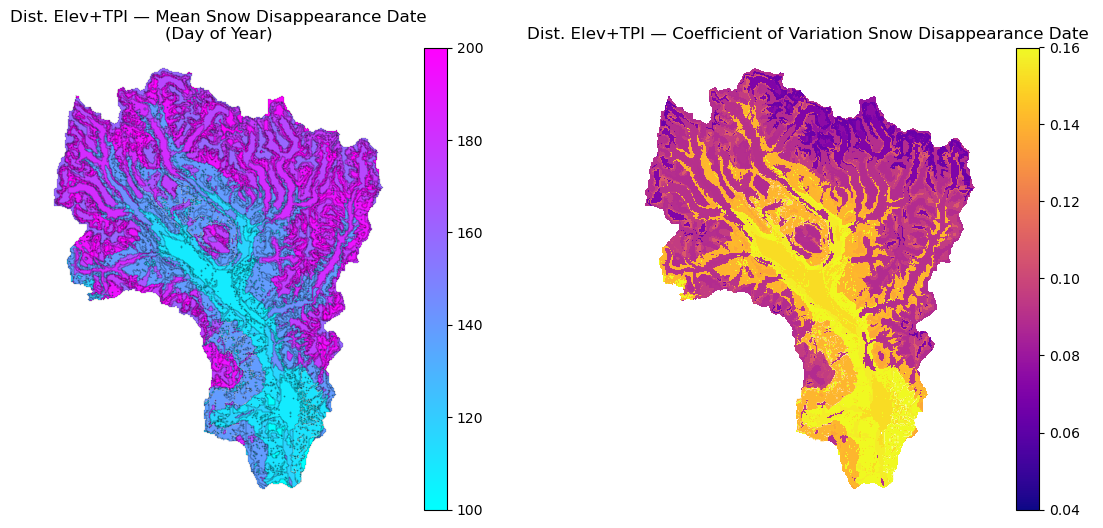

In [38]:

var_to_plot = 'scalarSnowDepth_mean'  # example variable

for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    shapefile_dir = shapefile_catchment_dirs[domain]
    # grab the first shapefile
    shapefile_path = glob(f"{shapefile_dir}/*.shp")[0]
    gdf = gpd.read_file(shapefile_path)
    
    ds = xr.open_dataset(model_files[domain]['bigBuckt'])
    # identify the first day of each year when snow disappears (snow depth < 20 mm)
    sdd_dict = {}
    for year in range(2002, 2022):
        snow_depth = ds['scalarSnowDepth_mean'].where(ds.time.dt.year == year, drop=True).to_pandas().resample('1D').mean()
        # for each column, identify first date when snow depth < 0.05 m (50 mm)
        snow_disappearance_date = (snow_depth < 0.0254).idxmax()
        # convert series to day of year
        sdd_dict[year] = snow_disappearance_date.dt.day_of_year
    sdd = pd.DataFrame(sdd_dict, index=ds['hru'].values).T
    sdd_mean = sdd.mean(axis=0)
    sdd_cv = sdd.std(axis=0) / sdd_mean
    gdf['mean_sdd'] = gdf['HRU_ID'].apply(lambda hru_id: float(sdd_mean.loc[hru_id]))
    gdf['cv_sdd'] = gdf['HRU_ID'].apply(lambda hru_id: float(sdd_cv.loc[hru_id]))

    ax = axs[0]
    gdf.plot(column='mean_sdd', cmap='cool', legend=True, ax=ax, vmin=100, vmax=200)
    # plot hru outlines
    gdf.boundary.plot(color='k', linewidth=0.2, ax=ax, alpha=0.5)
    ax.set_title(f"{domain_labels[domain]} — Mean Snow Disappearance Date\n(Day of Year)", fontsize=12)
    ax.set_axis_off()

    ax = axs[1]
    gdf.plot(column='cv_sdd', cmap='plasma', legend=True, ax=ax, vmin=0.04, vmax=0.16)
    ax.set_title(f"{domain_labels[domain]} — Coefficient of Variation Snow Disappearance Date ", fontsize=12)
    ax.set_axis_off()

## Water balance mean and standard deviation comparison

In [243]:
# make a 5 panel plot with the mean, and standard deviation of ET, peak streamflow, low flow, subsurface storage
# organize with bar charts for each model type (bars) in each domain (x-axis), with error bars showing the standard deviation across years.

# fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
# variables = ['annual_q', 'scalarTotalET', 'scalarSnowSublimation', 'scalar'

# use model_discharge dict to get peak 7-D mean streamflow for each year, then average across years and get std dev
peak_7d_q = {}
min_7d_q = {}
for domain in model_discharge.keys():
    for model_key in model_discharge[domain].keys():
        for wy in range(2002, 2022):
            sim_df = model_discharge[domain][model_key]
            # get the daily streamflow for this water year
            runoff_wy = sim_df.loc[f"{wy-1}-10-01":f"{wy}-09-30"]
            if len(runoff_wy) < 7:
                continue
            peak_7d_q[(domain, model_key, wy)] = runoff_wy.rolling(window=7).mean().max()
            min_7d_q[(domain, model_key, wy)] = runoff_wy.rolling(window=7).mean().min()

obs_peak_7d_q = {}
obs_min_7d_q = {}
for wy in range(2002, 2022):
    if wy not in obs_q_mm.index:
        continue
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if len(obs_wy) < 7:
        continue
    obs_peak_7d_q[(wy)] = obs_wy.rolling(window=7).mean().max()
    obs_min_7d_q[(wy)] = obs_wy.rolling(window=7).mean().min()


In [244]:

model_et = {}
for domain in model_discharge.keys():
    for model_key in model_discharge[domain].keys():
        filepath = model_files[domain][model_key]
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        # calculate weighted mean ET

        et_daily = ((-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
        et_daily = et_daily.resample('1D').sum()
        et_annual = et_daily.resample('YS-OCT').sum()
        et_annual = et_annual[et_annual.index.year <= 2021]
        et_annual.index = et_annual.index + pd.offsets.DateOffset(years=1)
        wys = et_annual.index.year
        for wy in wys:
            model_et[(domain, model_key, wy)] = et_annual.loc[et_annual.index.year == wy].values[0]


In [245]:
model_oct_1_soil_liq = {}
for (domain, model_key), sim_df in swe_daily_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
    ds = xr.open_dataset(filepath)
    if domain == 'bigBuckt':
        hru_areas = hru_areas.isel(hru=slice(None, -1))
        ds = ds.isel(hru=slice(None, -1))
    # calculate weighted mean ET
    if 'mLayerVolFracLiq' not in ds.data_vars:
        mlayer_frac_var = 'mLayerVolFracLiq_mean'
    else:
        mlayer_frac_var = 'mLayerVolFracLiq'
    soil_liq = ((ds[mlayer_frac_var]).sel(midToto=slice(None,3)).mean(dim='midToto').to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
    for date in pd.date_range(start='2001-09-30', end='2021-09-30', freq='YS-OCT'):
        soi_liq_oct1 = float(soil_liq.loc[date])
        model_oct_1_soil_liq[(domain, model_key, date.year + 1)] = soi_liq_oct1*100

In [246]:
for (domain, model_key), sim_df in annual_q_dict.items():
    
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarAquiferStorage_mean' not in ds.data_vars:
        continue
    aquifer_storage = ds['scalarAquiferStorage_mean'].mean(dim='hru').to_pandas()
    aquifer_storage = aquifer_storage.resample('1D').mean()
    aquifer_annual = aquifer_storage.resample('YE-SEP').max()
    # drop years after 2021
    aquifer_annual = aquifer_annual[(aquifer_annual.index.year <= 2021) & (aquifer_annual.index.year >= 2000)]
    # add 1 year to get water year
    aquifer_annual.index = aquifer_annual.index + pd.offsets.DateOffset(years=1)

In [266]:
model_total_wy_storage = {}
for (domain, model_key), sim_df in swe_daily_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
    ds = xr.open_dataset(filepath)

    soil_liq_var = None
    if 'scalarTotalSoilLiq' in ds.data_vars:
        soil_liq_var = 'scalarTotalSoilLiq'
    elif 'scalarTotalSoilLiq_mean' in ds.data_vars:
        soil_liq_var = 'scalarTotalSoilLiq_mean'

    soil_ice_var = None
    if 'scalarTotalSoilIce' in ds.data_vars:
        soil_ice_var = 'scalarTotalSoilIce'
    elif 'scalarTotalSoilIce_mean' in ds.data_vars:
        soil_ice_var = 'scalarTotalSoilIce_mean'

    soil_liq = _area_weighted_series(ds[soil_liq_var], hru_areas)
    soil_ice = _area_weighted_series(ds[soil_ice_var], hru_areas)

    aquifer_storage = ds['scalarAquiferStorage_mean'].mean(dim='hru').to_pandas()
    

    # group each by water year mean 
    soil_wy = (soil_liq+soil_ice).where(soil_liq.index.year > 2000).resample('YS-OCT').mean()
    aquifer_wy = aquifer_storage[(aquifer_storage.index.year <= 2021) & (aquifer_storage.index.year >= 2000)].resample('YS-OCT').mean()
    snow_storage = _area_weighted_series(ds['scalarSWE'], hru_areas) if 'scalarSWE' in ds.data_vars else soil_liq * 0.0
    snow_wy = snow_storage.where((snow_storage.index.year < 2021) & (snow_storage.index.year > 1999)).resample('YE-JUL').last().dropna()
    
    aquifer_mm = aquifer_wy.values

    soil_mm = soil_wy.values
    snow_mm = snow_wy.values
    
    if model_key == 'bigBuckt':
        total_mm = aquifer_mm * 1000 + soil_mm + snow_mm
    else:
        total_mm = soil_mm + snow_mm
        aquifer_mm = aquifer_mm * 0
    wy = soil_wy.index.year.values
    for i, wy in enumerate(wy):
        model_total_wy_storage[(domain, model_key, wy)] = [total_mm[i], soil_mm[i], aquifer_mm[i]*1000, snow_mm[i]]

In [267]:
# to pandas
min_7d_q = pd.Series(min_7d_q)
peak_7d_q = pd.Series(peak_7d_q)
model_et = pd.Series(model_et)
model_oct_1_soil_liq = pd.Series(model_oct_1_soil_liq)
# columns for storage
cols = ['total_storage', 'soil_storage', 'aquifer_storage', 'snow_storage']
model_total_wy_storage_df = pd.DataFrame.from_dict(model_total_wy_storage, orient='index', columns=cols)
model_total_wy_storage_df.index = pd.MultiIndex.from_tuples(model_total_wy_storage_df.index, names=['domain', 'model', 'water_year'])
# average across years and get std dev
peak_7d_q_stats = peak_7d_q.groupby(level=[0,1]).agg(['mean', 'std'])
min_7d_q_stats = min_7d_q.groupby(level=[0,1]).agg(['mean', 'std'])
model_et_stats = model_et.groupby(level=[0,1]).agg(['mean', 'std'])
model_oct_1_soil_liq_stats = model_oct_1_soil_liq.groupby(level=[0,1]).agg(['mean', 'std'])
model_total_wy_storage_stats = model_total_wy_storage_df.groupby(level=[0,1]).agg(['mean', 'std'])

# reorder index 
# model renames 
model_key_renames = {
    'noXplict_zeroFlux': 'Impermeable',
    'noXplict_drainage': 'Soil',
    'bigBuckt': 'Aquifer',
    'qTopmodl': 'Interflow',
}
domain_order = ['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']

In [268]:
# to pandas
min_7d_q = pd.Series(min_7d_q)
peak_7d_q = pd.Series(peak_7d_q)
model_et = pd.Series(model_et)
model_oct_1_soil_liq = pd.Series(model_oct_1_soil_liq)
# columns for storage
cols = ['total_storage', 'soil_storage', 'aquifer_storage', 'snow_storage']
model_total_wy_storage_df = pd.DataFrame.from_dict(model_total_wy_storage, orient='index', columns=cols)
model_total_wy_storage_df.index = pd.MultiIndex.from_tuples(model_total_wy_storage_df.index, names=['domain', 'model', 'water_year'])
# average across years and get std dev
peak_7d_q_stats = peak_7d_q.groupby(level=[0,1]).agg(['mean', 'std'])
min_7d_q_stats = min_7d_q.groupby(level=[0,1]).agg(['mean', 'std'])
model_et_stats = model_et.groupby(level=[0,1]).agg(['mean', 'std'])
model_oct_1_soil_liq_stats = model_oct_1_soil_liq.groupby(level=[0,1]).agg(['mean', 'std'])
model_total_wy_storage_stats = model_total_wy_storage_df.groupby(level=[0,1]).agg(['mean', 'std'])

# reorder index 
# model renames 
model_key_renames = {
    'noXplict_zeroFlux': 'Impermeable',
    'noXplict_drainage': 'Soil',
    'bigBuckt': 'Aquifer',
    'qTopmodl': 'Interflow',
}
domain_order = ['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']

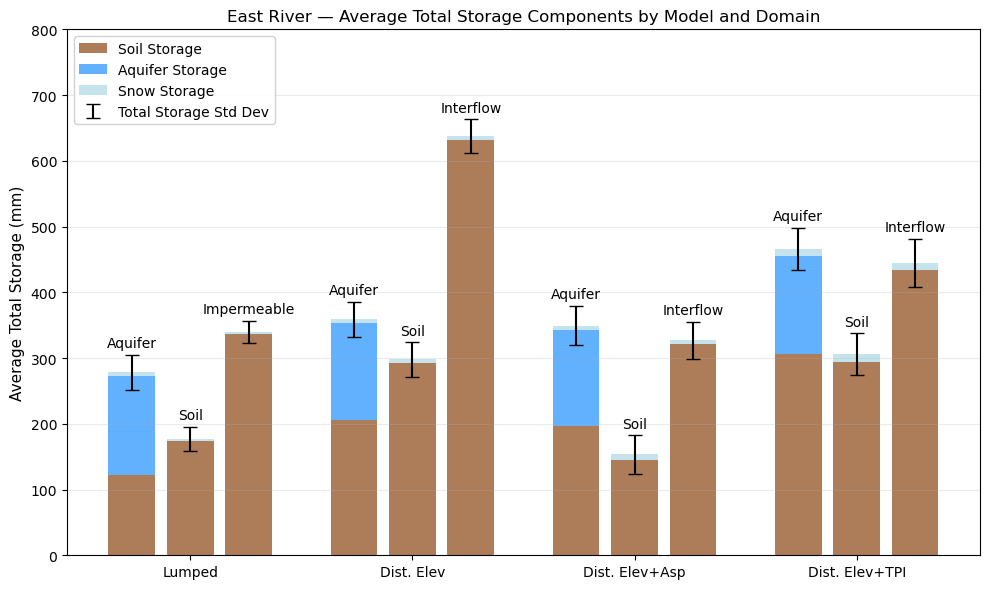

In [273]:
# make a stacked bar plot of the mean storage components, grouped by domain with model labels above each bar
fig, ax = plt.subplots(figsize=(10, 6))

gap = 0.8   # space between domain groups
x_positions = []
group_tick_positions = []
group_tick_labels = []
current_x = 0

# Build grouped x positions, iterating by domain_order
for domain in domain_order:
    if domain not in model_total_wy_storage_stats.index.get_level_values('domain'):
        continue
    group = model_total_wy_storage_stats.xs(domain, level='domain')
    group_start = current_x
    for model_key in group.index:
        x_positions.append((domain, model_key, current_x))
        current_x += 1
    group_tick_positions.append((group_start + current_x - 1) / 2)
    group_tick_labels.append(domain_labels.get(domain, domain))
    current_x += gap

x_arr = np.array([xi for _, _, xi in x_positions])
soil_arr    = np.array([model_total_wy_storage_stats.loc[(d, m), ('soil_storage',    'mean')] for d, m, _ in x_positions])
aquifer_arr = np.array([model_total_wy_storage_stats.loc[(d, m), ('aquifer_storage', 'mean')] for d, m, _ in x_positions])
snow_arr    = np.array([model_total_wy_storage_stats.loc[(d, m), ('snow_storage',    'mean')] for d, m, _ in x_positions])
total_std   = np.array([model_total_wy_storage_stats.loc[(d, m), ('total_storage',   'std')]  for d, m, _ in x_positions])
tops = soil_arr + aquifer_arr + snow_arr

ax.bar(x_arr, soil_arr,    label='Soil Storage',    color='#8B4513', alpha=0.7)
ax.bar(x_arr, aquifer_arr, bottom=soil_arr,         label='Aquifer Storage', color='#1E90FF', alpha=0.7)
ax.bar(x_arr, snow_arr,    bottom=soil_arr+aquifer_arr, label='Snow Storage', color='#ADD8E6', alpha=0.7)
ax.errorbar(x_arr, tops, yerr=total_std, fmt='none', ecolor='k', capsize=5, label='Total Storage Std Dev')

# Model key label above each bar
for (domain, model_key, xi), top, std in zip(x_positions, tops, total_std):
    label = model_key_renames.get(model_key, model_key)
    ax.text(xi, top + std + ax.get_ylim()[1] * 0.01, label,
            ha='center', va='bottom', fontsize=10, rotation=0)

ax.set_xticks(group_tick_positions)
ax.set_xticklabels(group_tick_labels, fontsize=10)
ax.set_ylabel('Average Total Storage (mm)', fontsize=11)
ax.set_title('East River — Average Total Storage Components by Model and Domain', fontsize=12)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25, axis='y')
ax.set_ylim(0,800)
plt.tight_layout()

/tmp/ipykernel_1733132/3606038341.py:6: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  obs_et_annual = obs_et_df.set_index('date').resample('AS-OCT').sum()['et']


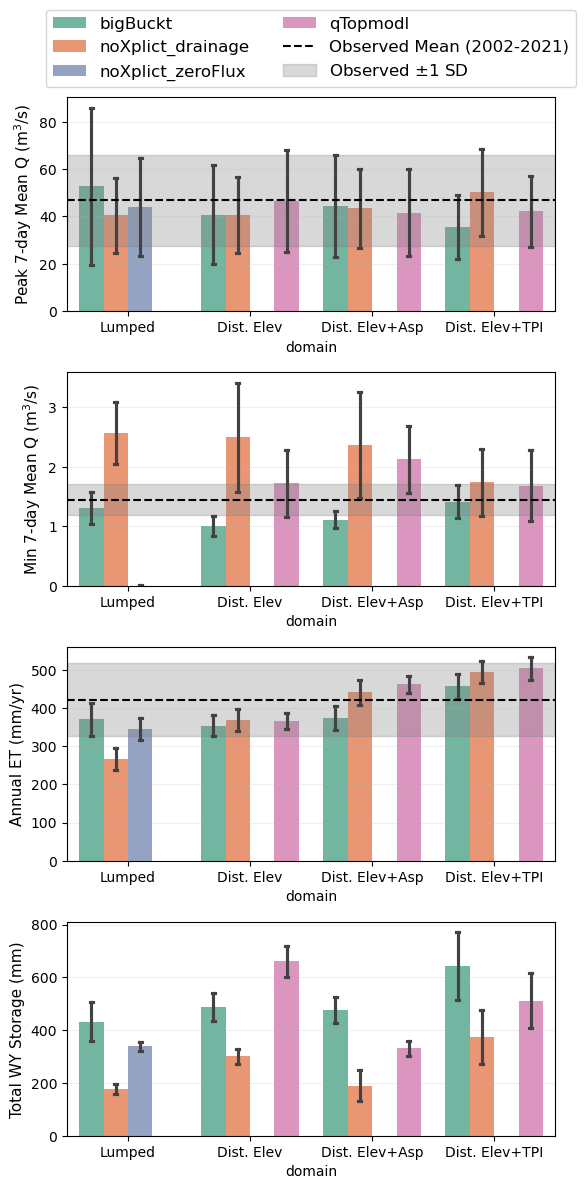

In [249]:
# Load observed ET and calculate annual mean and standard deviation
obs_et_df = pd.read_csv('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/observations/et/openet_et_ensemble_tuolumne_monthly.csv', parse_dates=['date'])
# skip winter months (Dec-Mar) to focus on growing season ET
obs_et_df = obs_et_df[~obs_et_df['date'].dt.month.isin([12, 1, 2])]
# Assuming the data is monthly, resample to water year (starting in October)
obs_et_annual = obs_et_df.set_index('date').resample('AS-OCT').sum()['et']
obs_et_mean = obs_et_annual.mean()
obs_et_std = obs_et_annual.std()

# calculate observed peak and min 7-day mean Q 
obs_peak_7d_q_series = pd.Series(obs_peak_7d_q)
obs_min_7d_q_series = pd.Series(obs_min_7d_q)

yaxis_labels = ['Peak 7-day Mean Q (m$^3$/s)', 'Min 7-day Mean Q (m$^3$/s)', 'Annual ET (mm/yr)', 'Total WY Storage (mm)']
fig, axes = plt.subplots(4, 1, figsize=(6, 12), tight_layout=True)
for i, (raw_data, title) in enumerate(zip([peak_7d_q, min_7d_q, model_et, model_total_wy_storage],
                                      yaxis_labels)):
    ax = axes[i]
    df = raw_data.reset_index(name='val')
    df['domain'] = df['level_0'].apply(lambda x: domain_labels.get(x, x))
    df['model'] = df['level_1']
    sns.barplot(data=df, x='domain', y='val', hue='model', ax=ax, errorbar='sd', capsize=0.1, palette='Set2', )
    if title in ['Peak 7-day Mean Q (m$^3$/s)', 'Min 7-day Mean Q (m$^3$/s)']:
        # Highlight observed Q on the Peak and Min 7-day Mean Q subplots
        obs_q_series = obs_peak_7d_q_series if 'Peak' in title else obs_min_7d_q_series
        h_line = ax.axhline(y=obs_q_series.mean(), color='k', linestyle='--', label='Observed Mean (2002-2021)')
        h_span = ax.axhspan(obs_q_series.mean() - obs_q_series.std(), obs_q_series.mean() + obs_q_series.std(), color='gray', alpha=0.3, label='Observed $\pm$1 SD')

    # Highlight observed ET on the Annual ET subplot
    if title == 'Annual ET (mm/yr)':
        h_line = ax.axhline(y=obs_et_mean, color='k', linestyle='--', label='Open ET Mean (2015-2021)')
        h_span = ax.axhspan(obs_et_mean - obs_et_std, obs_et_mean + obs_et_std, color='gray', alpha=0.3, label='Open ET $\pm$1 SD')
        
    
    if i == 0:
        ax.set_ylabel('Value', fontsize=11)
        ax.legend(ncol=2, bbox_to_anchor=(0.5, 1.45), loc='upper center', fontsize=12)
    else:
        ax.set_ylabel('')
        # For the Annual ET plot, keep only the observed legend items, for others remove the legend
        if title == 'Annual ET':
            handles, labels = ax.get_legend_handles_labels()
            # Extract just the lines we added (they appear at the end)
            ax.legend(handles[-2:], labels[-2:], loc='lower left', fontsize=10)
        else:
            if ax.legend_ is not None:
                ax.legend_.remove()
            
    ax.grid(True, alpha=0.2, axis='y')
    ax.set_ylim(0, None)
    ax.set_ylabel(yaxis_labels[i], fontsize=11)

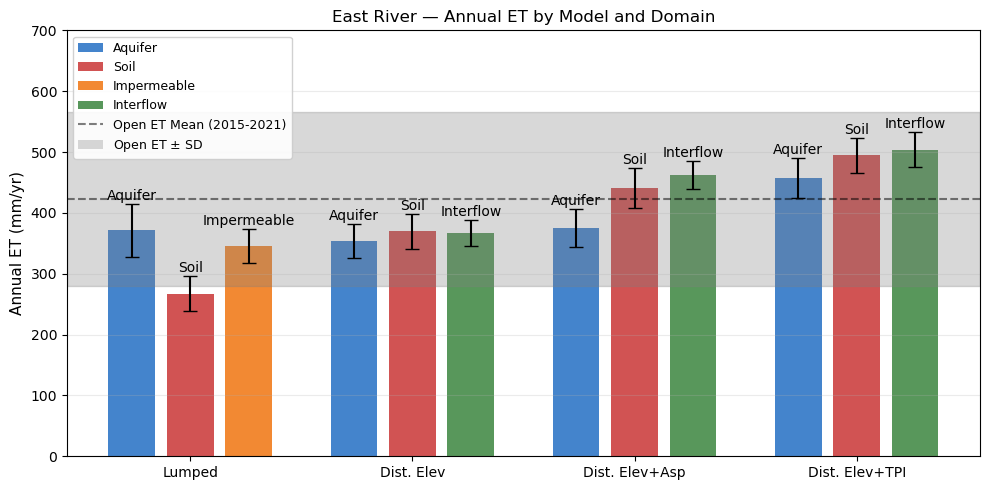

In [272]:
# ET by domain, bars colored by model type
fig, ax = plt.subplots(figsize=(10, 5))
# name model_et_stats level 1: domain, and level 2: model
model_et_stats.index.set_names(['domain', 'model'], inplace=True)
gap = 0.8
x_positions = []
group_tick_positions = []
group_tick_labels = []
current_x = 0

for domain in domain_order:
    lvl = model_et_stats.index.get_level_values("domain")
    if domain not in lvl:
        continue
    group = model_et_stats.xs(domain, level="domain")
    group_start = current_x
    for model_key in group.index:
        x_positions.append((domain, model_key, current_x))
        current_x += 1
    group_tick_positions.append((group_start + current_x - 1) / 2)
    group_tick_labels.append(domain_labels.get(domain, domain))
    current_x += gap

x_arr    = np.array([xi for _, _, xi in x_positions])
et_means = np.array([model_et_stats.loc[(d, m), "mean"] for d, m, _ in x_positions])
et_stds  = np.array([model_et_stats.loc[(d, m), "std"]  for d, m, _ in x_positions])
bar_colors = [model_colors.get(m, "gray") for _, m, _ in x_positions]

ax.bar(x_arr, et_means, color=bar_colors, alpha=0.8, width=0.8)
ax.errorbar(x_arr, et_means, yerr=et_stds, fmt="none", ecolor="k", capsize=5)

# model label above each bar
for (domain, model_key, xi), top, std in zip(x_positions, et_means, et_stds):
    label = model_key_renames.get(model_key, model_key)
    ax.text(xi, top + std + 2, label, ha="center", va="bottom", fontsize=10, rotation=0)

# observed ET reference
ax.axhline(y=obs_et_mean, color="k", linestyle="--", label="Open ET Mean (2015-2021)", alpha=0.5)
ax.axhspan(obs_et_mean - obs_et_std*1.5, obs_et_mean + obs_et_std*1.5,
           color="gray", alpha=0.3, label="Open ET $\pm$ SD")

# model color legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=model_colors[m], alpha=0.8, label=model_key_renames.get(m, m))
                  for m in model_colors if m in model_et_stats.index.get_level_values("model")]
ax.legend(handles=legend_handles + [
    plt.Line2D([0], [0], color="k", linestyle="--", label="Open ET Mean (2015-2021)", alpha=0.5),
    plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.3, label="Open ET $\pm$ SD"),
], fontsize=9, loc="upper left", framealpha=0.9)

ax.set_xticks(group_tick_positions)
ax.set_xticklabels(group_tick_labels, fontsize=10)
ax.set_ylabel("Annual ET (mm/yr)", fontsize=11)
ax.set_title("East River — Annual ET by Model and Domain", fontsize=12)
ax.set_ylim(0, 700)
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()


# Growing season (april-june) ET vs. snow disappearance date
Negative correlation indicates that growing season ET decreases with later snow disappearance date: if snow lasts longer, spring ET is less. 

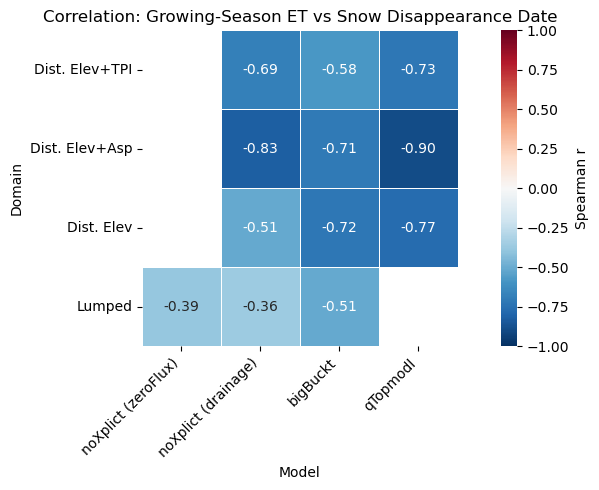

In [44]:
# Correlation heatmap: growing-season ET vs snow disappearance date (all model types)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
snow_threshold_m = 0.01
winter_months = [12, 1, 2, 3]
et_vars = ['scalarTotalET', 'scalarSnowSublimation', 'scalarSnowDepth_mean']
snow_months = [2, 3, 4, 5, 6]

for domain, models in model_files.items():
    for model_key, filepath in models.items():
        with xr.open_dataset(filepath) as ds:
            if any(v not in ds.data_vars for v in et_vars):
                continue
            ds = ds[et_vars].sel(time=time_slice)

            # Growing-season ET (exclude winter months), unweighted mean across HRUs
            et = -(ds['scalarTotalET']) * 3600
            et_mean = et.mean(dim='hru')
            et_gs = et_mean.where(et_mean['time.month'].isin([4,5,6]))
            et_gs_wy = et_gs.resample(time='YS-OCT').sum()

            # Snow disappearance date (last snow day in Apr-Sep), median across HRUs
            snow_depth_daily = ds['scalarSnowDepth_mean'].where(ds['time.month'].isin(snow_months)).resample(time='1D').mean()
            snow_present = snow_depth_daily > snow_threshold_m
            dayofyear = snow_depth_daily['time'].dt.dayofyear
            sdd = (snow_present * dayofyear).groupby('time.year').max('time')
            sdd = sdd.where(sdd > 0)
            sdd_med = sdd.median(dim='hru', skipna=True)

        et_s = et_gs_wy.to_pandas()
        sdd_s = sdd_med.to_pandas()
        et_s.index = (et_s.index + pd.offsets.DateOffset(years=1)).year
        sdd_s.index = sdd_s.index.astype(int)

        temp_df = pd.DataFrame({
            'et_gs': et_s,
            'sdd': sdd_s,
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['et_gs'].corr(temp_df['sdd'], method='spearman')
        records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Growing-Season ET vs Snow Disappearance Date')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Heatmap for spring ET and fall precipitation 

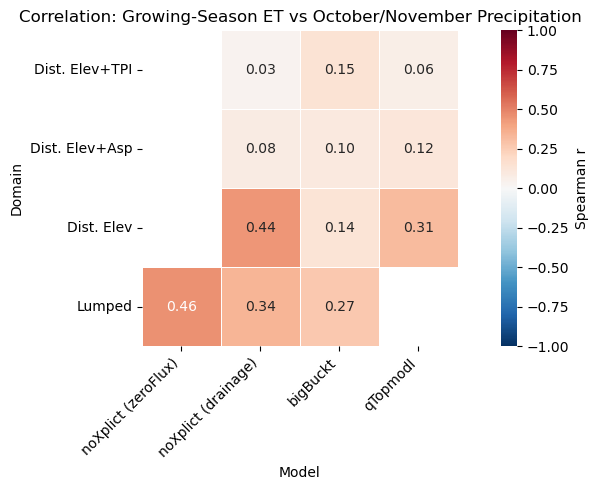

In [45]:
# Correlation heatmap: growing-season ET vs snow disappearance date (all model types)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
et_vars = ['scalarTotalET', 'scalarSnowSublimation', 'pptrate']
fall_months = [9, 10, 11]

for domain, models in model_files.items():
    for model_key, filepath in models.items():
        with xr.open_dataset(filepath) as ds:
            if any(v not in ds.data_vars for v in et_vars):
                continue
            ds = ds[et_vars].sel(time=time_slice)

            # Growing-season ET (exclude winter months), unweighted mean across HRUs
            et = -(ds['scalarTotalET']) * 3600
            et_mean = et.mean(dim='hru')
            et_gs = et_mean.where(et_mean['time.month'].isin([4,5,6]))
            et_gs_wy = et_gs.resample(time='YS-OCT').sum()

            # Snow disappearance date (last snow day in Apr-Sep), median across HRUs
            ppt_daily = ds['pptrate'].where(ds_p['time.month'].isin(fall_months))
            ppt_mean = ppt_daily.mean(dim='hru')
            ppt_gs = ppt_mean.where(ppt_mean['time.month'].isin(fall_months))
            ppt_gs_wy = ppt_gs.resample(time='YS-OCT').sum()

        et_s = et_gs_wy.to_pandas()
        spring_ppt_s = ppt_gs_wy.to_pandas()

        temp_df = pd.DataFrame({
            'et_gs': et_s,
            'spring_ppt': spring_ppt_s,
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['et_gs'].corr(temp_df['spring_ppt'], method='spearman')
        records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Growing-Season ET vs October/November Precipitation')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Heatmap for spring ET and spring precipitation 

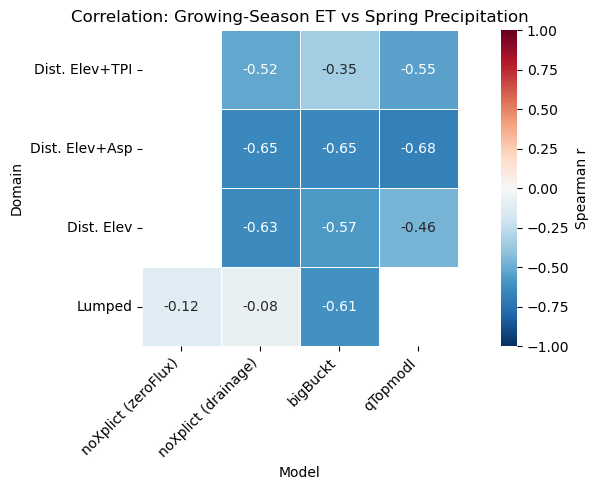

In [46]:
# Correlation heatmap: growing-season ET vs snow disappearance date (all model types)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
et_vars = ['scalarTotalET', 'scalarSnowSublimation', 'pptrate']
spring_months = [3, 4, 5,6]

for domain, models in model_files.items():
    for model_key, filepath in models.items():
        with xr.open_dataset(filepath) as ds:
            if any(v not in ds.data_vars for v in et_vars):
                continue
            ds = ds[et_vars].sel(time=time_slice)

            # Growing-season ET (exclude winter months), unweighted mean across HRUs
            et = -(ds['scalarTotalET']) * 3600
            et_mean = et.mean(dim='hru')
            et_gs = et_mean.where(et_mean['time.month'].isin([4,5,6]))
            et_gs_wy = et_gs.resample(time='YS-OCT').sum()

            # Snow disappearance date (last snow day in Apr-Sep), median across HRUs
            ppt_daily = ds['pptrate'].where(ds_p['time.month'].isin(spring_months))
            ppt_mean = ppt_daily.mean(dim='hru')
            ppt_gs = ppt_mean.where(ppt_mean['time.month'].isin(spring_months))
            ppt_gs_wy = ppt_gs.resample(time='YS-OCT').sum()

        et_s = et_gs_wy.to_pandas()
        spring_ppt_s = ppt_gs_wy.to_pandas()

        temp_df = pd.DataFrame({
            'et_gs': et_s,
            'spring_ppt': spring_ppt_s,
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['et_gs'].corr(temp_df['spring_ppt'], method='spearman')
        records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Growing-Season ET vs Spring Precipitation')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

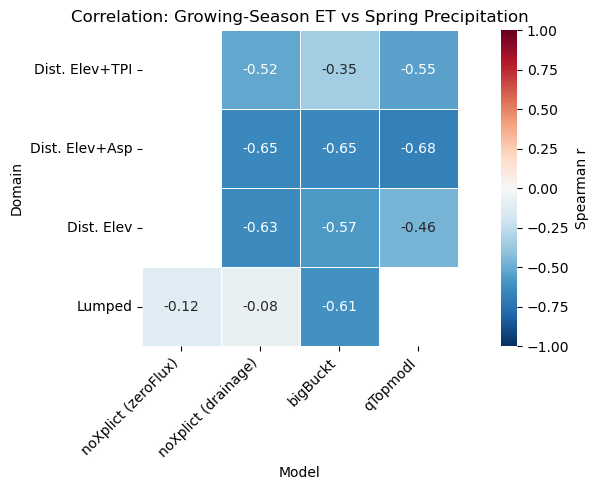

In [47]:
# Correlation heatmap: growing-season ET vs snow disappearance date (all model types)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
et_vars = ['scalarTotalET', 'scalarSnowSublimation', 'pptrate']
spring_months = [3, 4, 5, 6]

for domain, models in model_files.items():
    for model_key, filepath in models.items():
        with xr.open_dataset(filepath) as ds:
            if any(v not in ds.data_vars for v in et_vars):
                continue
            ds = ds[et_vars].sel(time=time_slice)

            # Growing-season ET (exclude winter months), unweighted mean across HRUs
            et = -(ds['scalarTotalET']) * 3600
            et_mean = et.mean(dim='hru')
            et_gs = et_mean.where(et_mean['time.month'].isin([4,5,6]))
            et_gs_wy = et_gs.resample(time='YS-OCT').sum()

            # Snow disappearance date (last snow day in Apr-Sep), median across HRUs
            ppt_daily = ds['pptrate'].where(ds_p['time.month'].isin(spring_months))
            ppt_mean = ppt_daily.mean(dim='hru')
            ppt_gs = ppt_mean.where(ppt_mean['time.month'].isin(spring_months))
            ppt_gs_wy = ppt_gs.resample(time='YS-OCT').sum()

        et_s = et_gs_wy.to_pandas()
        spring_ppt_s = ppt_gs_wy.to_pandas()

        temp_df = pd.DataFrame({
            'et_gs': et_s,
            'spring_ppt': spring_ppt_s,
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['et_gs'].corr(temp_df['spring_ppt'], method='spearman')
        records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Growing-Season ET vs Spring Precipitation')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Lag-1 ET anomaly (next water year vs. October 1 soil moisture)
Positive correlation means greater fall soil moisture correlates with greater spring ET

/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may imp

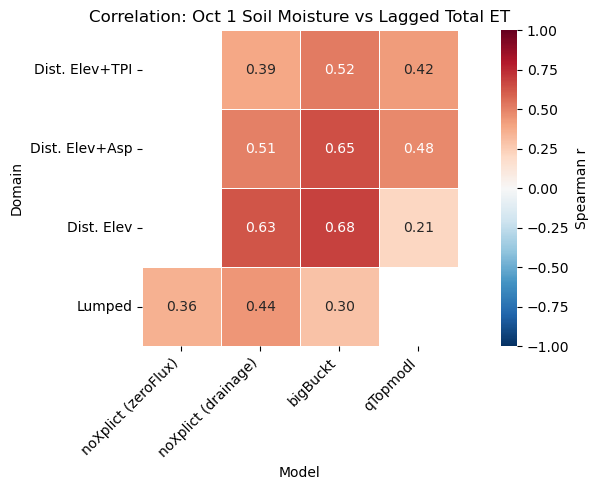

In [48]:
# Correlation heatmap: lag-1 ET anomaly vs Oct 1 soil moisture anomaly
records = []

for (domain, model_key), et_s in model_et.groupby(level=[0, 1]):
    et_s = et_s.droplevel([0, 1]).sort_index()
    soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()

    if et_s.std() == 0 or soil_s.std() == 0:
        continue

    et_s_anomaly = (et_s - et_s.mean()) / et_s.std()
    soil_s_anomaly = (soil_s - soil_s.mean()) / soil_s.std()

    # Lag total ET by 1 water year
    lag_et = et_s_anomaly.shift(1)

    temp_df = pd.DataFrame({
        'lag_et': lag_et,
        'oct1_soil': soil_s_anomaly,
    }).dropna()

    if temp_df.empty:
        continue

    corr_val = temp_df['lag_et'].corr(temp_df['oct1_soil'], method='spearman')
    records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Oct 1 Soil Moisture vs Lagged Total ET')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

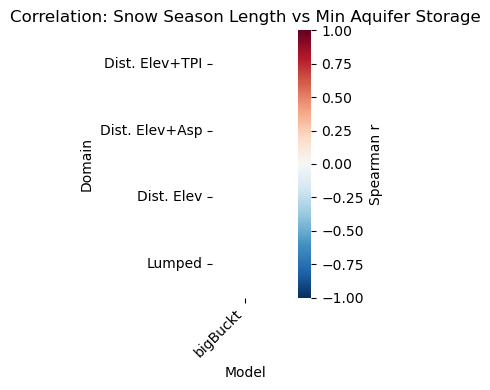

In [49]:
# Correlation heatmap: snow season length vs min aquifer storage (bigBuckt only)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
snow_threshold_m = 0.01

for domain, models in model_files.items():
    if 'bigBuckt' not in models:
        continue
    filepath = model_files[domain]['bigBuckt']
    with xr.open_dataset(filepath) as ds:
        needed_vars = ['scalarAquiferStorage_mean', 'scalarSnowDepth_mean']
        if any(v not in ds.data_vars for v in needed_vars):
            continue

        ds = ds[needed_vars].sel(time=time_slice)

        # Minimum aquifer storage per water year
        aquifer = ds['scalarAquiferStorage_mean'].mean(dim='hru')
        min_aquifer = aquifer.resample(time='YS-OCT').min()

        # Length of snow season (mean across HRUs)
        snow_depth_daily = ds['scalarSnowDepth_mean'].resample(time='1D').mean()
        snow_present_daily = snow_depth_daily > snow_threshold_m
        snow_season_length = (
            snow_present_daily.mean(dim='hru')
            .resample(time='YS-OCT')
            .sum(dim='time')
        )

    min_aquifer_s = min_aquifer.to_pandas()
    snow_season_s = snow_season_length.to_pandas()

    # Convert to water year labels
    min_aquifer_s.index = (min_aquifer_s.index + pd.offsets.DateOffset(years=1)).year
    snow_season_s.index = (snow_season_s.index + pd.offsets.DateOffset(years=1)).year

    temp_df = pd.DataFrame({
        'snow_len': snow_season_s,
        'min_aquifer': min_aquifer_s,
    }).dropna()

    if temp_df.empty:
        continue

    corr_val = temp_df['snow_len'].corr(temp_df['min_aquifer'], method='spearman')
    records.append({'domain': domain, 'model': 'bigBuckt', 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')
# Full labels
heatmap_df = heatmap_df.rename(columns={'bigBuckt': 'bigBuckt'})

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]

heatmap_df = heatmap_df.reindex(index=domain_order)

plt.figure(figsize=(4.5, 4))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Snow Season Length vs Min Aquifer Storage')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Aquifer storage and peak SWE lag correlation

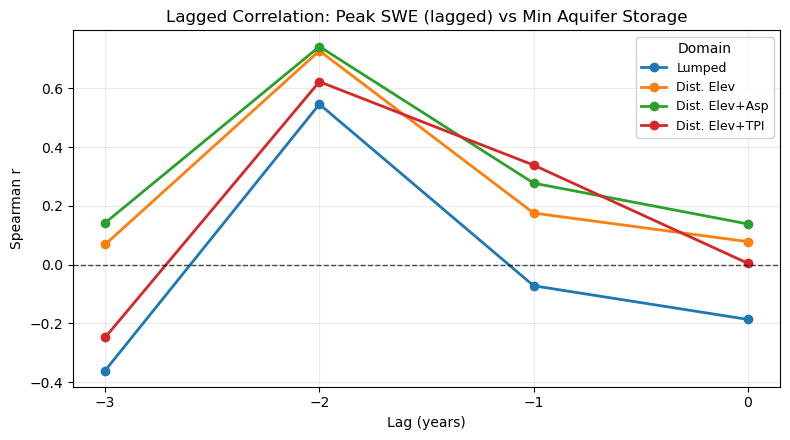

In [50]:
# Lagged correlation line plot: peak SWE vs min aquifer storage (bigBuckt only)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
lags = list(range(-3, 1))

for domain, models in model_files.items():
    if 'bigBuckt' not in models:
        continue
    filepath = model_files[domain]['bigBuckt']
    with xr.open_dataset(filepath) as ds:
        needed_vars = ['scalarAquiferStorage_mean', 'scalarSWE']
        if any(v not in ds.data_vars for v in needed_vars):
            continue

        ds = ds[needed_vars].sel(time=time_slice)

        # Minimum aquifer storage per water year
        aquifer = ds['scalarAquiferStorage_mean'].mean(dim='hru')
        min_aquifer = aquifer.resample(time='YS-OCT').min()

        # Peak SWE proxy (mean across selected HRUs)
        if len(ds.hru) > 1:
            scalar_swe = ds['scalarSWE'].sel(hru=slice(int(len(ds.hru) * 0.4), None)).resample(time='1D').mean()
        else:
            scalar_swe = ds['scalarSWE'].resample(time='1D').mean()

        peak_swe = (
            scalar_swe.max(dim='hru')
            .resample(time='YS-OCT')
            .sum(dim='time')
        )

    min_aquifer_s = min_aquifer.to_pandas()
    peak_swe_s = peak_swe.to_pandas()

    # Convert to water year labels
    min_aquifer_s.index = (min_aquifer_s.index + pd.offsets.DateOffset(years=1)).year
    peak_swe_s.index = (peak_swe_s.index + pd.offsets.DateOffset(years=1)).year

    for lag in lags:
        temp_df = pd.DataFrame({
            'peak_swe': peak_swe_s,
            'min_aquifer': min_aquifer_s.shift(-lag),
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['peak_swe'].corr(temp_df['min_aquifer'], method='spearman')
        records.append({'domain': domain, 'lag': lag, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for lagged correlation.')

corr_df = pd.DataFrame(records)
corr_df['domain_label'] = corr_df['domain'].map(domain_labels)
lag_pivot = corr_df.pivot(index='lag', columns='domain_label', values='corr').reindex(index=lags)

ordered_labels = [domain_labels[d] for d in domain_labels if d in corr_df['domain'].unique()]
lag_pivot = lag_pivot.reindex(columns=ordered_labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
for label in lag_pivot.columns:
    ax.plot(lag_pivot.index, lag_pivot[label], marker='o', linewidth=2, label=label)

ax.axhline(0, color='k', lw=1, ls='--', alpha=0.7)
ax.set_xticks(lags)
ax.set_xlabel('Lag (years)')
ax.set_ylabel('Spearman r')
ax.set_title('Lagged Correlation: Peak SWE (lagged) vs Min Aquifer Storage')
ax.grid(True, alpha=0.25)
ax.legend(title='Domain', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

## Spatial vs. Subsurface: Variance Decomposition

Two-factor decomposition using annual mean discharge as the metric. Spread is normalized IQR (IQR/median). Note: lumped runs do not include `qTopmodl`, and `noXplict` uses drainage only.

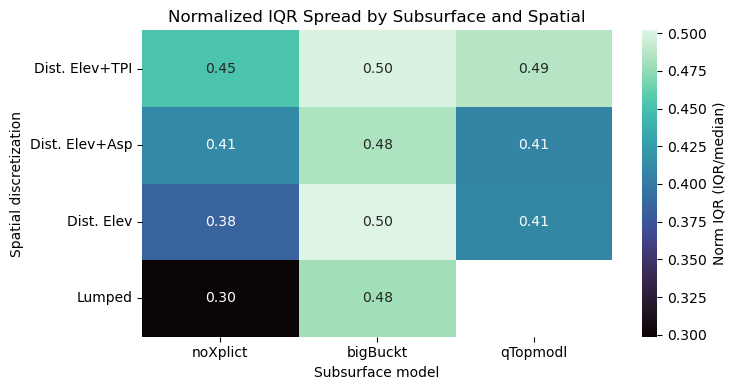

,norm_iqr_subsurface_mean,norm_iqr_spatial_mean,ratio_subsurface,ratio_spatial,ratio_sub_to_streamflow,ratio_spatial_to_streamflow
0,0.084202,0.086369,0.485449,0.514551,0.18424,0.193875


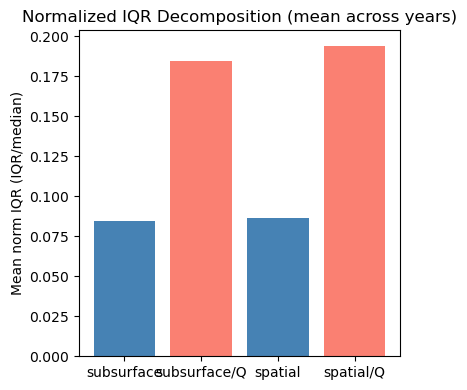

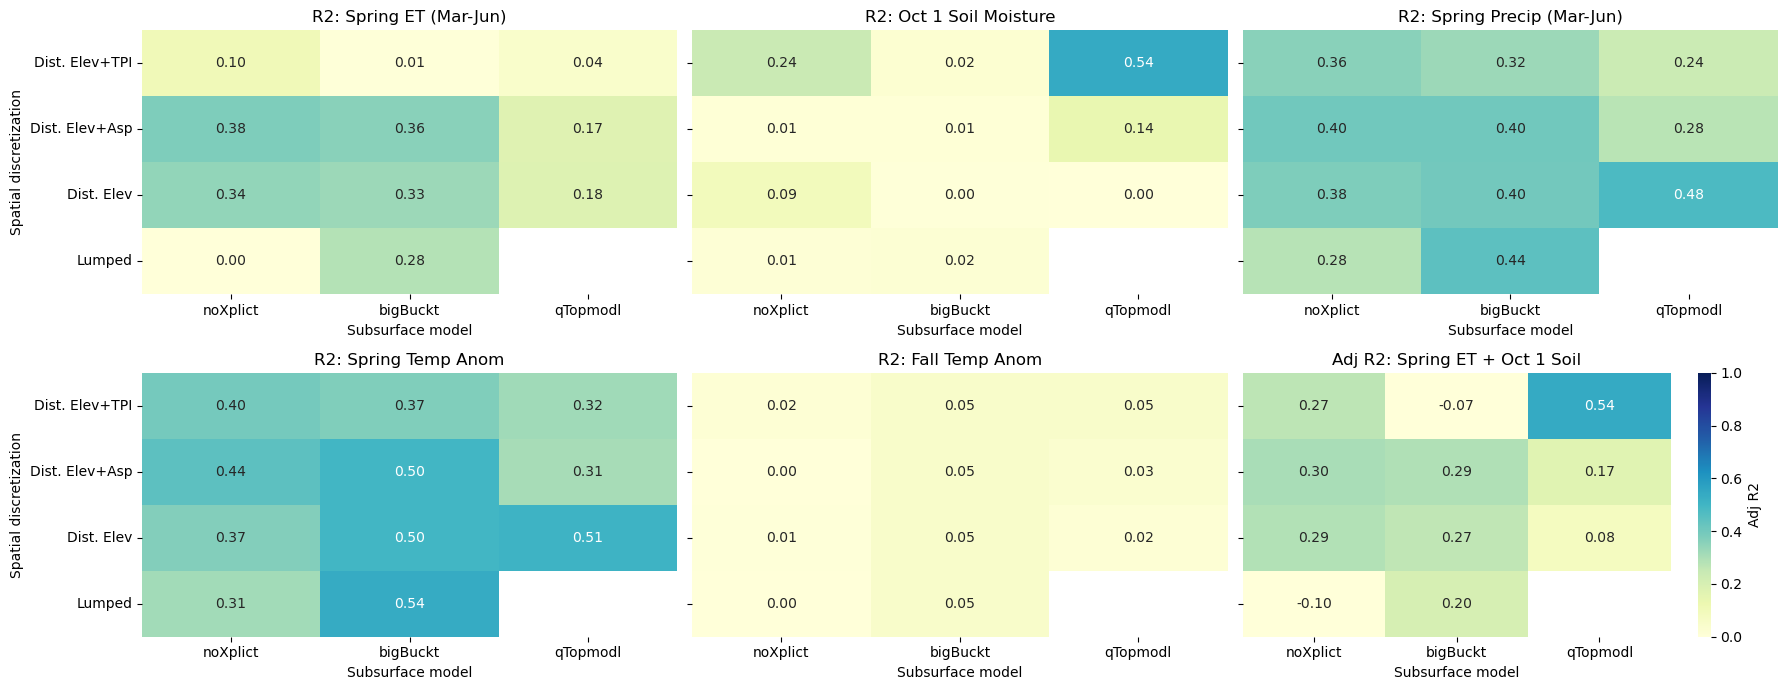

,spring_et,oct1_soil,spring_ppt,spring_temp,fall_temp,both_adj
subsurface,,,,,,
noXplict,0.205573,0.088321,0.354396,0.379569,0.006683,0.189170
bigBuckt,0.242955,0.014743,0.393264,0.476384,0.048722,0.171974
qTopmodl,0.132078,0.225920,0.330791,0.378889,0.032320,0.265326


In [51]:
# Build annual mean discharge table for variance decomposition

target_domains = ['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']
y_order = list(reversed(target_domains))
subsurface_map = {
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
    'noXplict_drainage': 'noXplict',
}
subsurface_order = ['noXplict', 'bigBuckt', 'qTopmodl']

def _combine_series(existing, new):
    if existing is None:
        return new
    return pd.concat([existing, new], axis=1).mean(axis=1)


def _norm_iqr(df, axis=0):
    q75 = df.quantile(0.75, axis=axis)
    q25 = df.quantile(0.25, axis=axis)
    med = df.median(axis=axis).replace(0, np.nan)
    return (q75 - q25) / med


def _norm_iqr_1d(series):
    q75 = series.quantile(0.75)
    q25 = series.quantile(0.25)
    med = series.median()
    if med == 0:
        return np.nan
    return (q75 - q25) / med


annual_q = {}
for domain in target_domains:
    for model_key, sim_df in model_discharge.get(domain, {}).items():
        subsurface = subsurface_map.get(model_key)
        if subsurface is None:
            continue
        q_wy = sim_df.resample('YS-OCT').mean()
        q_wy = q_wy[q_wy.index.year <= 2021]
        q_wy.index = q_wy.index
        key = (domain, subsurface)
        annual_q[key] = _combine_series(annual_q.get(key), q_wy)

annual_q_df = pd.DataFrame(annual_q)
annual_q_df.columns = pd.MultiIndex.from_tuples(annual_q_df.columns, names=['domain', 'subsurface'])
col_order = [(d, s) for d in target_domains for s in subsurface_order if (d, s) in annual_q_df.columns]
annual_q_df = annual_q_df.reindex(columns=pd.MultiIndex.from_tuples(col_order, names=['domain', 'subsurface']))
annual_q_df.index = annual_q_df.index.year

# Total timeseries spread (normalized IQR across years)
spread_norm = _norm_iqr(annual_q_df, axis=0)
spread_df = spread_norm.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
spread_df.index = [domain_labels[d] for d in spread_df.index]

plt.figure(figsize=(7.5, 4))
sns.heatmap(spread_df, annot=True, fmt='.2f', cmap='mako', cbar_kws={'label': 'Norm IQR (IQR/median)'})
plt.title('Normalized IQR Spread by Subsurface and Spatial')
plt.xlabel('Subsurface model')
plt.ylabel('Spatial discretization')
plt.tight_layout()
plt.show()

# Normalized IQR decomposition per year
domain_keys = annual_q_df.columns.get_level_values('domain').unique()
subsurface_keys = annual_q_df.columns.get_level_values('subsurface').unique()
sub_spread_by_domain = pd.concat(
    {
        d: _norm_iqr(annual_q_df.xs(d, level='domain', axis=1), axis=1)
        for d in domain_keys
    },
    axis=1,
)
spatial_spread_by_model = pd.concat(
    {
        s: _norm_iqr(annual_q_df.xs(s, level='subsurface', axis=1), axis=1)
        for s in subsurface_keys
    },
    axis=1,
)

spread_subsurface = sub_spread_by_domain.mean(axis=1)
spread_spatial = spatial_spread_by_model.mean(axis=1)

ratio_sub = spread_subsurface / (spread_subsurface + spread_spatial)
ratio_spatial = 1.0 - ratio_sub

streamflow_spread_by_domain = pd.Series(
    {
        d: _norm_iqr_1d(pd.Series(annual_q_df.xs(d, level='domain', axis=1).to_numpy().ravel()))
        for d in domain_keys
    }
)
streamflow_spread_by_model = pd.Series(
    {
        s: _norm_iqr_1d(pd.Series(annual_q_df.xs(s, level='subsurface', axis=1).to_numpy().ravel()))
        for s in subsurface_keys
    }
)
streamflow_spread_domain = streamflow_spread_by_domain.mean()
streamflow_spread_model = streamflow_spread_by_model.mean()
ratio_sub_to_flow = float(spread_subsurface.mean() / streamflow_spread_domain)
ratio_spatial_to_flow = float(spread_spatial.mean() / streamflow_spread_model)

decomp_summary = pd.DataFrame(
    {
        'norm_iqr_subsurface_mean': [spread_subsurface.mean()],
        'norm_iqr_spatial_mean': [spread_spatial.mean()],
        'ratio_subsurface': [ratio_sub.mean()],
        'ratio_spatial': [ratio_spatial.mean()],
        'ratio_sub_to_streamflow': [ratio_sub_to_flow],
        'ratio_spatial_to_streamflow': [ratio_spatial_to_flow],
    }
)
display(decomp_summary)

bar_values = [
    float(spread_subsurface.mean()),
    ratio_sub_to_flow,
    float(spread_spatial.mean()),
    ratio_spatial_to_flow,
 ]
plt.figure(figsize=(4.2, 4))
plt.bar(['subsurface', 'subsurface/Q', 'spatial', 'spatial/Q'], bar_values, color=['steelblue', 'salmon', 'steelblue', 'salmon'])
plt.ylabel('Mean norm IQR (IQR/median)')
plt.title('Normalized IQR Decomposition (mean across years)')
plt.tight_layout()
plt.show()

# Spring ET and Oct/Nov 1 soil moisture contributions

def _r2_pair(x, y):
    df = pd.concat([x, y], axis=1).dropna()
    if len(df) < 3:
        return np.nan
    return np.corrcoef(df.iloc[:, 0], df.iloc[:, 1])[0, 1] ** 2


def _r2_both(x, y1, y2):
    df = pd.concat([x, y1, y2], axis=1).dropna()
    if len(df) < 3:
        return np.nan
    X = df.iloc[:, 1:3].values
    y = df.iloc[:, 0].values
    reg = LinearRegression().fit(X, y)
    return reg.score(X, y)


def _r2_both_adj(x, y1, y2):
    df = pd.concat([x, y1, y2], axis=1).dropna()
    if len(df) < 4:
        return np.nan
    X = df.iloc[:, 1:3].values
    y = df.iloc[:, 0].values
    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)
    n = len(df)
    p = X.shape[1]
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


spring_months = [3, 4, 5, 6]
fall_months = [9, 10, 11]
spring_et = {}
soil_oct1 = {}
spring_ppt = {}
spring_temp = {}
fall_temp = {}

for domain in target_domains:
    with xr.open_dataset(attr_paths[domain]) as attrs:
        hru_areas = attrs['HRUarea'].load()
    for model_key, filepath in model_files[domain].items():
        subsurface = subsurface_map.get(model_key)
        if subsurface is None:
            continue
        with xr.open_dataset(filepath) as ds:
            if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
                continue
            et_daily_df = (-ds['scalarTotalET'] * 3600).to_pandas()
            et_daily = (et_daily_df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
            et_daily = et_daily.resample('1D').sum()
            spring_daily = et_daily[et_daily.index.month.isin(spring_months)]
            spring_wy = spring_daily.resample('YS-OCT').sum()
            spring_wy = spring_wy[spring_wy.index.year <= 2021]
            spring_wy.index = spring_wy.index.year
            key = (domain, subsurface)
            spring_et[key] = _combine_series(spring_et.get(key), spring_wy)

            soil_var = None
            if 'scalarTotalSoilLiq' in ds.data_vars:
                soil_var = 'scalarTotalSoilLiq'
            elif 'scalarTotalSoilLiq_mean' in ds.data_vars:
                soil_var = 'scalarTotalSoilLiq_mean'
            if soil_var is None:
                continue
            soil_df = (ds[soil_var].to_pandas() * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
            soil_df.index = pd.to_datetime(soil_df.index)

            dates_oct = pd.date_range(start='2001-10-01', end='2021-10-01', freq='YS-OCT')
            soil_oct = soil_df.reindex(dates_oct, method='nearest')
            soil_oct.index = soil_oct.index.year - 1
            soil_oct = pd.Series(soil_oct.values, index=soil_oct.index)
            soil_oct1[key] = _combine_series(soil_oct1.get(key), soil_oct)

            if 'pptrate' in ds.data_vars:
                p_rate = ds['pptrate']
                p_daily_df = (p_rate * 86400).to_pandas()
                p_daily = (p_daily_df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
                p_daily = p_daily.resample('1D').mean()
                spring_p_daily = p_daily[p_daily.index.month.isin(spring_months)]
                spring_p_wy = spring_p_daily.resample('YS-OCT').sum()
                spring_p_wy = spring_p_wy[spring_p_wy.index.year <= 2021]
                spring_p_wy.index = spring_p_wy.index.year
                spring_ppt[key] = _combine_series(spring_ppt.get(key), spring_p_wy)

            if 'airtemp' in ds.data_vars:
                t_daily_df = ds['airtemp'].to_pandas()
                t_daily = (t_daily_df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
                t_daily = t_daily.resample('1D').mean()
                spring_t_daily = t_daily[t_daily.index.month.isin(spring_months)]
                spring_t_wy = spring_t_daily.resample('YS-OCT').mean()
                spring_t_wy = spring_t_wy[spring_t_wy.index.year <= 2021]
                spring_t_wy.index = spring_t_wy.index.year
                spring_temp[key] = _combine_series(spring_temp.get(key), spring_t_wy)

                fall_t_daily = t_daily[t_daily.index.month.isin(fall_months)]
                fall_t_wy = fall_t_daily.resample('YS-OCT').mean()
                fall_t_wy = fall_t_wy[fall_t_wy.index.year <= 2021]
                fall_t_wy.index = fall_t_wy.index.year
                fall_temp[key] = _combine_series(fall_temp.get(key), fall_t_wy)

spring_et_df = pd.DataFrame(spring_et)
spring_et_df.columns = pd.MultiIndex.from_tuples(spring_et_df.columns, names=['domain', 'subsurface'])
spring_et_df = spring_et_df.reindex(columns=annual_q_df.columns)

soil_oct_df = pd.DataFrame(soil_oct1)
soil_oct_df.columns = pd.MultiIndex.from_tuples(soil_oct_df.columns, names=['domain', 'subsurface'])
soil_oct_df = soil_oct_df.reindex(columns=annual_q_df.columns)

spring_ppt_df = pd.DataFrame(spring_ppt)
spring_ppt_df.columns = pd.MultiIndex.from_tuples(spring_ppt_df.columns, names=['domain', 'subsurface'])
spring_ppt_df = spring_ppt_df.reindex(columns=annual_q_df.columns)

spring_temp_df = pd.DataFrame(spring_temp)
spring_temp_df.columns = pd.MultiIndex.from_tuples(spring_temp_df.columns, names=['domain', 'subsurface'])
spring_temp_df = spring_temp_df.reindex(columns=annual_q_df.columns)

fall_temp_df = pd.DataFrame(fall_temp)
fall_temp_df.columns = pd.MultiIndex.from_tuples(fall_temp_df.columns, names=['domain', 'subsurface'])
fall_temp_df = fall_temp_df.reindex(columns=annual_q_df.columns)

annual_q_anom = annual_q_df - annual_q_df.mean(axis=0)
spring_et_anom = spring_et_df - spring_et_df.mean(axis=0)
soil_oct_anom = soil_oct_df - soil_oct_df.mean(axis=0)
spring_ppt_anom = spring_ppt_df - spring_ppt_df.mean(axis=0)
spring_temp_anom = spring_temp_df - spring_temp_df.mean(axis=0)
fall_temp_anom = fall_temp_df - fall_temp_df.mean(axis=0)

r2_spring = {col: _r2_pair(annual_q_anom[col], spring_et_anom[col]) for col in annual_q_df.columns}
r2_oct = {col: _r2_pair(annual_q_anom[col], soil_oct_anom[col]) for col in annual_q_df.columns}
r2_spring_ppt = {col: _r2_pair(annual_q_anom[col], spring_ppt_anom[col]) for col in annual_q_df.columns}
r2_spring_temp = {col: _r2_pair(annual_q_anom[col], spring_temp_anom[col]) for col in annual_q_df.columns}
r2_fall_temp = {col: _r2_pair(annual_q_anom[col], fall_temp_anom[col]) for col in annual_q_df.columns}
r2_both_adj = {col: _r2_both_adj(annual_q_anom[col], spring_et_anom[col], soil_oct_anom[col]) for col in annual_q_df.columns}

r2_spring_series = pd.Series(r2_spring)
r2_spring_series.index = pd.MultiIndex.from_tuples(r2_spring_series.index, names=['domain', 'subsurface'])
r2_oct_series = pd.Series(r2_oct)
r2_oct_series.index = pd.MultiIndex.from_tuples(r2_oct_series.index, names=['domain', 'subsurface'])
r2_spring_ppt_series = pd.Series(r2_spring_ppt)
r2_spring_ppt_series.index = pd.MultiIndex.from_tuples(r2_spring_ppt_series.index, names=['domain', 'subsurface'])
r2_spring_temp_series = pd.Series(r2_spring_temp)
r2_spring_temp_series.index = pd.MultiIndex.from_tuples(r2_spring_temp_series.index, names=['domain', 'subsurface'])
r2_fall_temp_series = pd.Series(r2_fall_temp)
r2_fall_temp_series.index = pd.MultiIndex.from_tuples(r2_fall_temp_series.index, names=['domain', 'subsurface'])
r2_both_adj_series = pd.Series(r2_both_adj)
r2_both_adj_series.index = pd.MultiIndex.from_tuples(r2_both_adj_series.index, names=['domain', 'subsurface'])

r2_spring_df = r2_spring_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_oct_df = r2_oct_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_spring_ppt_df = r2_spring_ppt_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_spring_temp_df = r2_spring_temp_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_fall_temp_df = r2_fall_temp_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_both_adj_df = r2_both_adj_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)

r2_spring_df.index = [domain_labels[d] for d in r2_spring_df.index]
r2_oct_df.index = [domain_labels[d] for d in r2_oct_df.index]
r2_spring_ppt_df.index = [domain_labels[d] for d in r2_spring_ppt_df.index]
r2_spring_temp_df.index = [domain_labels[d] for d in r2_spring_temp_df.index]
r2_fall_temp_df.index = [domain_labels[d] for d in r2_fall_temp_df.index]
r2_both_adj_df.index = [domain_labels[d] for d in r2_both_adj_df.index]

fig, axes = plt.subplots(2, 3, figsize=(18, 7), sharey=True)
axes = axes.ravel()
sns.heatmap(r2_spring_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title('R2: Spring ET (Mar-Jun)')
axes[0].set_xlabel('Subsurface model')
axes[0].set_ylabel('Spatial discretization')

sns.heatmap(r2_oct_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title('R2: Oct 1 Soil Moisture')
axes[1].set_xlabel('Subsurface model')

sns.heatmap(r2_spring_ppt_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[2], cbar=False)
axes[2].set_title('R2: Spring Precip (Mar-Jun)')
axes[2].set_xlabel('Subsurface model')

sns.heatmap(r2_spring_temp_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[3], cbar=False)
axes[3].set_title('R2: Spring Temp Anom')
axes[3].set_xlabel('Subsurface model')
axes[3].set_ylabel('Spatial discretization')

sns.heatmap(r2_fall_temp_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[4], cbar=False)
axes[4].set_title('R2: Fall Temp Anom')
axes[4].set_xlabel('Subsurface model')

sns.heatmap(r2_both_adj_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[5], cbar_kws={'label': 'Adj R2'})
axes[5].set_title('Adj R2: Spring ET + Oct 1 Soil')
axes[5].set_xlabel('Subsurface model')

plt.tight_layout()
plt.show()

r2_summary = pd.DataFrame(
    {
        'spring_et': r2_spring_df.mean(axis=0),
        'oct1_soil': r2_oct_df.mean(axis=0),
        'spring_ppt': r2_spring_ppt_df.mean(axis=0),
        'spring_temp': r2_spring_temp_df.mean(axis=0),
        'fall_temp': r2_fall_temp_df.mean(axis=0),
        'both_adj': r2_both_adj_df.mean(axis=0),
    }
)
display(r2_summary)